In [121]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import geopandas as gpd
    HAS_GPD = True
except Exception as e:
    HAS_GPD = False
    print("geopandas not available (maps will be skipped):", e)

DATA_RAW = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")
OUTPUTS_DIR = Path("../outputs")
TABLES_DIR = OUTPUTS_DIR / "tables"

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

def clean_city_name(x):
    """Normalize city/jurisdiction names for joins."""
    if pd.isna(x):
        return x
    x = str(x).upper().strip()
    x = re.sub(r"\s*\(.*?\)\s*", " ", x)   
    x = re.sub(r"[^A-Z0-9\s]", " ", x)    
    x = re.sub(r"\s+", " ", x).strip()
    return x

def profile_df(df, name, max_show=5):
    print("\n" + "="*90)
    print(name)
    print("shape:", df.shape)
    print("columns:")
    for c in df.columns[:60]:
        print("  -", c)
    if len(df.columns) > 60:
        print("  ...")
    print("\nhead:")
    display(df.head(max_show))
    miss = df.isna().mean().sort_values(ascending=False).head(15)
    print("\nmissing % (top 15):")
    display(miss)

def find_first_file(patterns):
    """Return the first matching file in DATA_RAW for any pattern."""
    for pat in patterns:
        matches = sorted(DATA_RAW.glob(pat))
        if matches:
            return matches[0]
    return None

In [122]:
if HAS_GPD:
    muni_path = DATA_RAW / "Municipal_Boundaries.geojson"
    county_path = DATA_RAW / "San_Diego_County_Boundary.geojson"

    muni = gpd.read_file(muni_path)
    county = gpd.read_file(county_path)

    muni["jur_clean"] = muni["Name"].map(clean_city_name)

    sd_muni_names = sorted(set(muni["jur_clean"].dropna().tolist()))
    
    sd_muni_names = [
        "CARLSBAD","CHULA VISTA","CORONADO","DEL MAR","EL CAJON","ENCINITAS",
        "ESCONDIDO","IMPERIAL BEACH","LA MESA","LEMON GROVE","NATIONAL CITY",
        "OCEANSIDE","POWAY","SAN DIEGO","SAN MARCOS","SANTEE","SOLANA BEACH","VISTA"
    ]

    print("SD muni count:", len(sd_muni_names))
    print(sd_muni_names)
    
    profile_df(muni, "Municipal Boundaries (muni)")
    profile_df(county, "County Boundary (county)")

    print("\nCount of muni features:", len(muni))
    print("Unique muni names:", len(sd_muni_names))
    print("First 30 muni names:", sd_muni_names[:30])
else:
    raise RuntimeError("Install geopandas to use boundary geojson files.")

SD muni count: 18
['CARLSBAD', 'CHULA VISTA', 'CORONADO', 'DEL MAR', 'EL CAJON', 'ENCINITAS', 'ESCONDIDO', 'IMPERIAL BEACH', 'LA MESA', 'LEMON GROVE', 'NATIONAL CITY', 'OCEANSIDE', 'POWAY', 'SAN DIEGO', 'SAN MARCOS', 'SANTEE', 'SOLANA BEACH', 'VISTA']

Municipal Boundaries (muni)
shape: (73, 16)
columns:
  - OBJECTID
  - Name
  - CREATEDBY
  - CREATEDDATE
  - UPDATEDBY
  - UPDATEDATE
  - GlobalID
  - CODE
  - DOCYR
  - DOCNO
  - DOCDATE
  - SUBJECT
  - Shape_Length
  - Shape_Area
  - geometry
  - jur_clean

head:


,OBJECTID,Name,CREATEDBY,CREATEDDATE,UPDATEDBY,UPDATEDATE,GlobalID,CODE,DOCYR,DOCNO,DOCDATE,SUBJECT,Shape_Length,Shape_Area,geometry,jur_clean
0,1,S.D. COUNTY,jack_quartic,1677174094000,drewdowling,1686602520000,{00000000-0000-0000-0000-000000000000},CN,NaN,NaN,NaN,NaN,1419.389616,1.107826e+05,"POLYGON ((-117.22558 33.10971, -117.22558 33.1...",S D COUNTY
1,2,ESCONDIDO,KPalm_SanGIS,1701985562000,KPalm_SanGIS,1772126594000,{00000000-0000-0000-0000-000000000000},ES,NaN,NaN,NaN,NaN,554795.580723,1.043566e+09,"POLYGON ((-117.06339 33.21156, -117.0648 33.21...",ESCONDIDO
2,3,S.D. COUNTY,jack_quartic,1677174094000,drewdowling,1686602520000,{00000000-0000-0000-0000-000000000000},CN,NaN,NaN,NaN,NaN,8530.539568,2.056224e+06,"POLYGON ((-117.22558 33.10984, -117.22558 33.1...",S D COUNTY
3,4,VISTA,drewdowling,1686600846000,KPalm_SanGIS,1772055021000,{00000000-0000-0000-0000-000000000000},VS,NaN,NaN,NaN,NaN,272525.175055,5.237087e+08,"POLYGON ((-117.25524 33.23762, -117.25534 33.2...",VISTA
4,5,S.D. COUNTY,jack_quartic,1677174094000,drewdowling,1686602520000,{00000000-0000-0000-0000-000000000000},CN,NaN,NaN,NaN,NaN,12030.699268,4.424856e+06,"POLYGON ((-117.24886 33.17178, -117.24844 33.1...",S D COUNTY



missing % (top 15):


DOCYR           0.917808
DOCNO           0.917808
DOCDATE         0.917808
SUBJECT         0.917808
OBJECTID        0.000000
Name            0.000000
CREATEDBY       0.000000
CREATEDDATE     0.000000
UPDATEDBY       0.000000
UPDATEDATE      0.000000
GlobalID        0.000000
CODE            0.000000
Shape_Length    0.000000
Shape_Area      0.000000
geometry        0.000000
dtype: float64


County Boundary (county)
shape: (1, 5)
columns:
  - OBJECTID
  - TRANUM
  - Shape_Length
  - Shape_Area
  - geometry

head:


,OBJECTID,TRANUM,Shape_Length,Shape_Area,geometry
0,1,88888888,1.569192e+06,1.187874e+11,"POLYGON ((-117.48762 33.50506, -117.49341 33.5..."



missing % (top 15):


OBJECTID        0.0
TRANUM          0.0
Shape_Length    0.0
Shape_Area      0.0
geometry        0.0
dtype: float64


Count of muni features: 73
Unique muni names: 18
First 30 muni names: ['CARLSBAD', 'CHULA VISTA', 'CORONADO', 'DEL MAR', 'EL CAJON', 'ENCINITAS', 'ESCONDIDO', 'IMPERIAL BEACH', 'LA MESA', 'LEMON GROVE', 'NATIONAL CITY', 'OCEANSIDE', 'POWAY', 'SAN DIEGO', 'SAN MARCOS', 'SANTEE', 'SOLANA BEACH', 'VISTA']


In [123]:
apr_a_path  = DATA_RAW / "tablea.csv"
apr_a2_path = DATA_RAW / "tablea2.csv"
apr_c_path  = DATA_RAW / "tablec.csv"
apr_f_path  = DATA_RAW / "tablef.csv"

apr_a  = pd.read_csv(apr_a_path, low_memory=False)
apr_a2 = pd.read_csv(apr_a2_path, low_memory=False)
apr_c  = pd.read_csv(apr_c_path, low_memory=False)
apr_f  = pd.read_csv(apr_f_path, low_memory=False)

rhna6_path = DATA_RAW / "rhna_progress_6.csv"
rhna6 = pd.read_csv(rhna6_path, low_memory=False)

rhna5_path = find_first_file(["cff0bc49-*.csv", "*rhna*5*.csv"])
if rhna5_path is None:
    print("WARNING: RHNA5 file not found. Skipping.")
    rhna5 = None
else:
    rhna5 = pd.read_csv(rhna5_path, low_memory=False)

profile_df(apr_a,  "APR Table A (apr_a)")
profile_df(apr_a2, "APR Table A2 (apr_a2)")
profile_df(apr_c,  "APR Table C (apr_c)")
profile_df(apr_f,  "APR Table F (apr_f)")
profile_df(rhna6,  "RHNA 6th Cycle (rhna6)")
if rhna5 is not None:
    profile_df(rhna5, "RHNA 5th Cycle (rhna5)")


APR Table A (apr_a)
shape: (302408, 27)
columns:
  - JURIS_NAME
  - CNTY_NAME
  - YEAR
  - PRIOR_APN
  - APN
  - STREET_ADDRESS
  - PROJECT_NAME
  - JURS_TRACKING_ID
  - UNIT_CAT
  - TENURE
  - APP_SUBMIT_DT
  - VLOW_INCOME_DR
  - VLOW_INCOME_NDR
  - LOW_INCOME_DR
  - LOW_INCOME_NDR
  - MOD_INCOME_DR
  - MOD_INCOME_NDR
  - ABOVE_MOD_INCOME
  - TOT_PROPOSED_UNITS
  - TOT_APPROVED_UNITS
  - TOT_DISAPPROVED_UNITS
  - APP_SUBMITTED_SB35
  - DENSITY_BONUS_RECEIVED
  - DENSITY_BONUS_APPROVED
  - APPLICATION_STATUS
  - PROJECT_TYPE
  - NOTES

head:


,JURIS_NAME,CNTY_NAME,YEAR,PRIOR_APN,APN,STREET_ADDRESS,PROJECT_NAME,JURS_TRACKING_ID,UNIT_CAT,TENURE,APP_SUBMIT_DT,VLOW_INCOME_DR,VLOW_INCOME_NDR,LOW_INCOME_DR,LOW_INCOME_NDR,MOD_INCOME_DR,MOD_INCOME_NDR,ABOVE_MOD_INCOME,TOT_PROPOSED_UNITS,TOT_APPROVED_UNITS,TOT_DISAPPROVED_UNITS,APP_SUBMITTED_SB35,DENSITY_BONUS_RECEIVED,DENSITY_BONUS_APPROVED,APPLICATION_STATUS,PROJECT_TYPE,NOTES
0,LONG BEACH,Los Angeles,2021,NaN,7268008014,1483 Martin Luther King Jr Ave,2102-15,2102-15,ADU,Renter,2021-02-08,0,0,0,0,0.0,0,2,2,2,0,No,No,NaN,Approved,NaN,NaN
1,LONG BEACH,Los Angeles,2021,NaN,7209016015,1845 Locust Ave,2110-43,2110-43,ADU,Renter,2021-10-28,0,0,0,0,0.0,0,1,1,0,0,No,No,NaN,Pending,NaN,NaN
2,LONG BEACH,Los Angeles,2021,NaN,7431024005,1900 Harbor Avenue,2108-23,2108-23,ADU,Renter,2021-08-20,0,0,0,0,0.0,0,1,1,0,0,No,No,NaN,Pending,NaN,NaN
3,LONG BEACH,Los Angeles,2021,NaN,7262003025,2525 E. 10th St,2101-18,2101-18,ADU,Renter,2021-01-19,0,0,0,0,0.0,0,2,2,2,0,No,No,NaN,Approved,NaN,NaN
4,LONG BEACH,Los Angeles,2021,NaN,7139008001,450 E. San Antonio Dr,2108-15,2108-15,ADU,Renter,2021-08-11,0,0,0,0,0.0,0,2,2,2,0,No,No,NaN,Approved,NaN,NaN



missing % (top 15):


PRIOR_APN                 0.910727
NOTES                     0.860572
DENSITY_BONUS_APPROVED    0.726912
PROJECT_TYPE              0.642288
PROJECT_NAME              0.623006
APPLICATION_STATUS        0.367391
DENSITY_BONUS_RECEIVED    0.367375
APP_SUBMITTED_SB35        0.350662
JURS_TRACKING_ID          0.113297
STREET_ADDRESS            0.018912
APN                       0.003905
UNIT_CAT                  0.000496
MOD_INCOME_DR             0.000489
MOD_INCOME_NDR            0.000489
TENURE                    0.000489
dtype: float64


APR Table A2 (apr_a2)
shape: (787329, 52)
columns:
  - JURIS_NAME
  - CNTY_NAME
  - YEAR
  - PRIOR_APN
  - APN
  - STREET_ADDRESS
  - PROJECT_NAME
  - JURS_TRACKING_ID
  - UNIT_CAT
  - TENURE
  - VLOW_INCOME_DR
  - VLOW_INCOME_NDR
  - LOW_INCOME_DR
  - LOW_INCOME_NDR
  - MOD_INCOME_DR
  - MOD_INCOME_NDR
  - ABOVE_MOD_INCOME
  - ENT_APPROVE_DT1
  - NO_ENTITLEMENTS
  - BP_VLOW_INCOME_DR
  - BP_VLOW_INCOME_NDR
  - BP_LOW_INCOME_DR
  - BP_LOW_INCOME_NDR
  - BP_MOD_INCOME_DR
  - BP_MOD_INCOME_NDR
  - BP_ABOVE_MOD_INCOME
  - BP_ISSUE_DT1
  - NO_BUILDING_PERMITS
  - CO_VLOW_INCOME_DR
  - CO_VLOW_INCOME_NDR
  - CO_LOW_INCOME_DR
  - CO_LOW_INCOME_NDR
  - CO_MOD_INCOME_DR
  - CO_MOD_INCOME_NDR
  - CO_ABOVE_MOD_INCOME
  - CO_ISSUE_DT1
  - NO_OTHER_FORMS_OF_READINESS
  - EXTR_LOW_INCOME_UNITS
  - APPROVE_SB35
  - INFILL_UNITS
  - FIN_ASSIST_NAME
  - DR_TYPE
  - NO_FA_DR
  - TERM_AFF_DR
  - DEM_DES_UNITS
  - DEM_OR_DES_UNITS
  - DEM_DES_UNITS_OWN_RENT
  - DENSITY_BONUS_TOTAL
  - DENSITY_BONUS_NUMB

...

Jurisdiction         0.0
Planning Period      0.0
6th Cycle Started    0.0
VLI UNITS            0.0
RHNA VLI             0.0
VLI %                0.0
LI UNITS             0.0
RHNA LI              0.0
LI %                 0.0
MOD UNITS            0.0
RHNA MOD             0.0
MOD %                0.0
ABOVE MOD UNITS      0.0
RHNA ABOVE MOD       0.0
ABOVE MOD %          0.0
dtype: float64


RHNA 5th Cycle (rhna5)
shape: (539, 15)
columns:
  - _id
  - Jurisdiction
  - Planning Period
  - VLI UNITS
  - RHNA VLI
  - VLI %
  - LI UNITS
  - RHNA LI
  - LI %
  - MOD UNITS
  - RHNA MOD
  - MOD %
  - ABOVE MOD UNITS
  - RHNA ABOVE MOD
  - ABOVE MOD %

head:


,_id,Jurisdiction,Planning Period,VLI UNITS,RHNA VLI,VLI %,LI UNITS,RHNA LI,LI %,MOD UNITS,RHNA MOD,MOD %,ABOVE MOD UNITS,RHNA ABOVE MOD,ABOVE MOD %
0,1,ADELANTO,10/15/2013 - 10/15/2021,0,632,0.00,0,459,0.00,0,513,0.00,140,1236,0.11
1,2,ANGELS CAMP,06/30/2014 - 06/30/2019,1,39,0.03,2,25,0.08,8,28,0.29,97,69,1.41
2,3,AGOURA HILLS,10/15/2013 - 10/15/2021,4,31,0.13,0,19,0.00,0,20,0.00,58,45,1.29
3,4,AMADOR,06/30/2014 - 09/15/2021,0,1,0.00,0,1,0.00,0,0,0.00,0,0,0.00
4,5,ANTIOCH,01/31/2015 - 01/31/2023,207,349,0.59,319,205,1.56,92,214,0.43,1939,680,2.85



missing % (top 15):


_id                0.0
Jurisdiction       0.0
Planning Period    0.0
VLI UNITS          0.0
RHNA VLI           0.0
VLI %              0.0
LI UNITS           0.0
RHNA LI            0.0
LI %               0.0
MOD UNITS          0.0
RHNA MOD           0.0
MOD %              0.0
ABOVE MOD UNITS    0.0
RHNA ABOVE MOD     0.0
ABOVE MOD %        0.0
dtype: float64

In [124]:
for df in [apr_a, apr_a2]:
    df["CNTY_NAME"] = df["CNTY_NAME"].astype(str).str.strip()
    df["jur_clean"] = df["JURIS_NAME"].map(clean_city_name)

apr_a_sd  = apr_a[(apr_a["CNTY_NAME"] == "San Diego") & (apr_a["jur_clean"].isin(sd_muni_names))].copy()
apr_a2_sd = apr_a2[(apr_a2["CNTY_NAME"] == "San Diego") & (apr_a2["jur_clean"].isin(sd_muni_names))].copy()

apr_c["COUNTY"] = apr_c["COUNTY"].astype(str).str.strip()
apr_c["jur_clean"] = apr_c["JURISDICTION"].map(clean_city_name)
apr_c_sd = apr_c[(apr_c["COUNTY"] == "San Diego") & (apr_c["jur_clean"].isin(sd_muni_names))].copy()

apr_f["jur_clean"] = apr_f["JURISDICTION_NAME"].map(clean_city_name)
apr_f_sd = apr_f[apr_f["jur_clean"].isin(sd_muni_names)].copy()

print("APR A SD:", apr_a_sd.shape)
print("APR A2 SD:", apr_a2_sd.shape)
print("APR C SD:", apr_c_sd.shape)
print("APR F SD:", apr_f_sd.shape)

profile_df(apr_a2_sd, "APR A2 (SD only)")

APR A SD: (18069, 28)
APR A2 SD: (33116, 53)
APR C SD: (369, 22)
APR F SD: (9, 14)

APR A2 (SD only)
shape: (33116, 53)
columns:
  - JURIS_NAME
  - CNTY_NAME
  - YEAR
  - PRIOR_APN
  - APN
  - STREET_ADDRESS
  - PROJECT_NAME
  - JURS_TRACKING_ID
  - UNIT_CAT
  - TENURE
  - VLOW_INCOME_DR
  - VLOW_INCOME_NDR
  - LOW_INCOME_DR
  - LOW_INCOME_NDR
  - MOD_INCOME_DR
  - MOD_INCOME_NDR
  - ABOVE_MOD_INCOME
  - ENT_APPROVE_DT1
  - NO_ENTITLEMENTS
  - BP_VLOW_INCOME_DR
  - BP_VLOW_INCOME_NDR
  - BP_LOW_INCOME_DR
  - BP_LOW_INCOME_NDR
  - BP_MOD_INCOME_DR
  - BP_MOD_INCOME_NDR
  - BP_ABOVE_MOD_INCOME
  - BP_ISSUE_DT1
  - NO_BUILDING_PERMITS
  - CO_VLOW_INCOME_DR
  - CO_VLOW_INCOME_NDR
  - CO_LOW_INCOME_DR
  - CO_LOW_INCOME_NDR
  - CO_MOD_INCOME_DR
  - CO_MOD_INCOME_NDR
  - CO_ABOVE_MOD_INCOME
  - CO_ISSUE_DT1
  - NO_OTHER_FORMS_OF_READINESS
  - EXTR_LOW_INCOME_UNITS
  - APPROVE_SB35
  - INFILL_UNITS
  - FIN_ASSIST_NAME
  - DR_TYPE
  - NO_FA_DR
  - TERM_AFF_DR
  - DEM_DES_UNITS
  - DEM_OR_DES_UN

,JURIS_NAME,CNTY_NAME,YEAR,PRIOR_APN,APN,STREET_ADDRESS,PROJECT_NAME,JURS_TRACKING_ID,UNIT_CAT,TENURE,VLOW_INCOME_DR,VLOW_INCOME_NDR,LOW_INCOME_DR,LOW_INCOME_NDR,MOD_INCOME_DR,MOD_INCOME_NDR,ABOVE_MOD_INCOME,ENT_APPROVE_DT1,NO_ENTITLEMENTS,BP_VLOW_INCOME_DR,BP_VLOW_INCOME_NDR,BP_LOW_INCOME_DR,BP_LOW_INCOME_NDR,BP_MOD_INCOME_DR,BP_MOD_INCOME_NDR,BP_ABOVE_MOD_INCOME,BP_ISSUE_DT1,NO_BUILDING_PERMITS,CO_VLOW_INCOME_DR,CO_VLOW_INCOME_NDR,CO_LOW_INCOME_DR,CO_LOW_INCOME_NDR,CO_MOD_INCOME_DR,CO_MOD_INCOME_NDR,CO_ABOVE_MOD_INCOME,CO_ISSUE_DT1,NO_OTHER_FORMS_OF_READINESS,EXTR_LOW_INCOME_UNITS,APPROVE_SB35,INFILL_UNITS,FIN_ASSIST_NAME,DR_TYPE,NO_FA_DR,TERM_AFF_DR,DEM_DES_UNITS,DEM_OR_DES_UNITS,DEM_DES_UNITS_OWN_RENT,DENSITY_BONUS_TOTAL,DENSITY_BONUS_NUMBER_OTHER_INCENTIVES,DENSITY_BONUS_INCENTIVES,DENSITY_BONUS_RECEIVE_REDUCTION,NOTES,jur_clean
5821,SOLANA BEACH,San Diego,2023,NaN,263-311-13,256 Pacific Ave,Hester,DRP22-018,SFD,Owner,0,0,0,0,0,0,1,2023-10-11,1,0.0,0,0,0.0,0.0,0.0,0,NaN,0,0,0,0,0.0,0,0,0,NaN,0,0,NONE,Y,NaN,NaN,0,NaN,0,0,0,0,0,NaN,NaN,NaN,SOLANA BEACH
5822,SOLANA BEACH,San Diego,2023,NaN,298-082-30,309 S Nardo Ave,Marcos,B22-0221,ADU,Renter,0,0,0,0,0,0,0,NaN,0,0.0,0,0,0.0,1.0,0.0,0,2023-02-09,1,0,0,0,0.0,1,0,0,2023-05-03,1,0,NONE,Y,Other,Other,JADU,NaN,0,0,0,0,0,NaN,NaN,NaN,SOLANA BEACH
5823,SOLANA BEACH,San Diego,2023,NaN,263-500-27,402 Santa Dominga,Lamantia ADU,B22-0749,ADU,Renter,0,0,0,0,0,0,0,NaN,0,0.0,0,0,0.0,0.0,1.0,0,2023-05-25,1,0,0,0,0.0,0,0,0,NaN,0,0,NONE,Y,NaN,NaN,ADU,NaN,0,0,0,0,0,NaN,NaN,NaN,SOLANA BEACH
5824,SOLANA BEACH,San Diego,2023,NaN,263-332-10,203 N Acacia Ave,Sullivan ADU,B23-0164,ADU,Renter,0,0,0,0,0,0,0,NaN,0,0.0,0,0,0.0,0.0,1.0,0,2023-08-02,1,0,0,0,0.0,0,0,0,NaN,0,0,NONE,Y,NaN,NaN,ADU,NaN,0,0,0,0,0,NaN,NaN,NaN,SOLANA BEACH
5825,SOLANA BEACH,San Diego,2023,NaN,298-380-23,1106 Highland Dr,Braun ADU,B23-0345,ADU,Renter,0,0,0,0,0,0,0,NaN,0,0.0,0,0,0.0,0.0,1.0,0,2023-11-13,1,0,0,0,0.0,0,0,0,NaN,0,0,NONE,Y,NaN,NaN,ADU,NaN,0,0,0,0,0,NaN,NaN,NaN,SOLANA BEACH



missing % (top 15):


DENSITY_BONUS_RECEIVE_REDUCTION    0.982999
DENSITY_BONUS_INCENTIVES           0.982758
FIN_ASSIST_NAME                    0.967840
DR_TYPE                            0.958238
TERM_AFF_DR                        0.957694
NOTES                              0.935167
ENT_APPROVE_DT1                    0.911885
PRIOR_APN                          0.910617
CO_ISSUE_DT1                       0.596419
BP_ISSUE_DT1                       0.340077
PROJECT_NAME                       0.338930
JURS_TRACKING_ID                   0.030469
NO_FA_DR                           0.005224
APN                                0.002386
DEM_DES_UNITS                      0.001419
dtype: float64

In [125]:
apr_a2_sd["YEAR"] = pd.to_numeric(apr_a2_sd["YEAR"], errors="coerce")

bp_cols = [
    "BP_VLOW_INCOME_DR","BP_VLOW_INCOME_NDR","BP_LOW_INCOME_DR","BP_LOW_INCOME_NDR",
    "BP_MOD_INCOME_DR","BP_MOD_INCOME_NDR","BP_ABOVE_MOD_INCOME"
]
co_cols = [
    "CO_VLOW_INCOME_DR","CO_VLOW_INCOME_NDR","CO_LOW_INCOME_DR","CO_LOW_INCOME_NDR",
    "CO_MOD_INCOME_DR","CO_MOD_INCOME_NDR","CO_ABOVE_MOD_INCOME"
]

for c in bp_cols + co_cols:
    apr_a2_sd[c] = pd.to_numeric(apr_a2_sd[c], errors="coerce").fillna(0)

grp = (
    apr_a2_sd.dropna(subset=["jur_clean","YEAR"])
             .groupby(["jur_clean","YEAR"], as_index=False)[bp_cols + co_cols]
             .sum()
)

grp["bp_units_total"] = grp[bp_cols].sum(axis=1)
grp["co_units_total"] = grp[co_cols].sum(axis=1)

bp_aff_cols = bp_cols[:-1]
co_aff_cols = co_cols[:-1]
grp["bp_affordable_total"] = grp[bp_aff_cols].sum(axis=1)
grp["co_affordable_total"] = grp[co_aff_cols].sum(axis=1)

grp["bp_affordable_share"] = np.where(grp["bp_units_total"] > 0,
                                      grp["bp_affordable_total"] / grp["bp_units_total"], np.nan)
grp["co_affordable_share"] = np.where(grp["co_units_total"] > 0,
                                      grp["co_affordable_total"] / grp["co_units_total"], np.nan)

apr_city_year_sd = grp.rename(columns={"YEAR": "year"})

profile_df(apr_city_year_sd, "APR A2 SD: city-year totals (BP vs CO)")

apr_city_year_sd.to_csv(DATA_PROCESSED / "sd_apr_a2_city_year_supply.csv", index=False)
print("Wrote:", DATA_PROCESSED / "sd_apr_a2_city_year_supply.csv")


APR A2 SD: city-year totals (BP vs CO)
shape: (126, 22)
columns:
  - jur_clean
  - year
  - BP_VLOW_INCOME_DR
  - BP_VLOW_INCOME_NDR
  - BP_LOW_INCOME_DR
  - BP_LOW_INCOME_NDR
  - BP_MOD_INCOME_DR
  - BP_MOD_INCOME_NDR
  - BP_ABOVE_MOD_INCOME
  - CO_VLOW_INCOME_DR
  - CO_VLOW_INCOME_NDR
  - CO_LOW_INCOME_DR
  - CO_LOW_INCOME_NDR
  - CO_MOD_INCOME_DR
  - CO_MOD_INCOME_NDR
  - CO_ABOVE_MOD_INCOME
  - bp_units_total
  - co_units_total
  - bp_affordable_total
  - co_affordable_total
  - bp_affordable_share
  - co_affordable_share

head:


,jur_clean,year,BP_VLOW_INCOME_DR,BP_VLOW_INCOME_NDR,BP_LOW_INCOME_DR,BP_LOW_INCOME_NDR,BP_MOD_INCOME_DR,BP_MOD_INCOME_NDR,BP_ABOVE_MOD_INCOME,CO_VLOW_INCOME_DR,CO_VLOW_INCOME_NDR,CO_LOW_INCOME_DR,CO_LOW_INCOME_NDR,CO_MOD_INCOME_DR,CO_MOD_INCOME_NDR,CO_ABOVE_MOD_INCOME,bp_units_total,co_units_total,bp_affordable_total,co_affordable_total,bp_affordable_share,co_affordable_share
0,CARLSBAD,2018,0.0,0.0,4.0,1.0,0.0,28.0,210.0,0.0,0.0,3.0,1.0,0.0,21.0,193.0,243.0,218.0,33.0,25.0,0.135802,0.114679
1,CARLSBAD,2019,0.0,2.0,47.0,2.0,0.0,59.0,212.0,0.0,0.0,111.0,0.0,56.0,22.0,359.0,322.0,548.0,110.0,189.0,0.341615,0.344891
2,CARLSBAD,2020,45.0,1.0,29.0,3.0,0.0,39.0,260.0,0.0,2.0,21.0,2.0,0.0,24.0,502.0,377.0,551.0,117.0,49.0,0.310345,0.088929
3,CARLSBAD,2021,0.0,2.0,4.0,3.0,0.0,65.0,76.0,0.0,1.0,48.0,2.0,0.0,70.0,288.0,150.0,409.0,74.0,121.0,0.493333,0.295844
4,CARLSBAD,2022,0.0,0.0,0.0,0.0,0.0,82.0,43.0,48.0,0.0,2.0,0.0,0.0,65.0,105.0,125.0,220.0,82.0,115.0,0.656000,0.522727



missing % (top 15):


co_affordable_share    0.047619
year                   0.000000
bp_affordable_share    0.000000
co_affordable_total    0.000000
bp_affordable_total    0.000000
co_units_total         0.000000
bp_units_total         0.000000
CO_ABOVE_MOD_INCOME    0.000000
CO_MOD_INCOME_NDR      0.000000
CO_MOD_INCOME_DR       0.000000
CO_LOW_INCOME_NDR      0.000000
jur_clean              0.000000
CO_VLOW_INCOME_NDR     0.000000
CO_VLOW_INCOME_DR      0.000000
BP_ABOVE_MOD_INCOME    0.000000
dtype: float64

Wrote: ../data/processed/sd_apr_a2_city_year_supply.csv


In [126]:
def rhna_prepare(df, label):
    df = df.copy()
    df["jur_clean"] = df["Jurisdiction"].map(clean_city_name)

    df_sd = df[df["jur_clean"].isin(sd_muni_names)].copy()

    num_cols = ["VLI UNITS","RHNA VLI","LI UNITS","RHNA LI","MOD UNITS","RHNA MOD","ABOVE MOD UNITS","RHNA ABOVE MOD"]
    for c in num_cols:
        if c in df_sd.columns:
            df_sd[c] = pd.to_numeric(df_sd[c], errors="coerce")

    df_sd["units_reported_total"] = df_sd[["VLI UNITS","LI UNITS","MOD UNITS","ABOVE MOD UNITS"]].sum(axis=1)
    df_sd["rhna_target_total"] = df_sd[["RHNA VLI","RHNA LI","RHNA MOD","RHNA ABOVE MOD"]].sum(axis=1)

    df_sd["pct_achieved"] = np.where(df_sd["rhna_target_total"]>0,
                                     df_sd["units_reported_total"]/df_sd["rhna_target_total"], np.nan)
    df_sd["cycle_label"] = label
    return df_sd

rhna6_sd = rhna_prepare(rhna6, "RHNA6")
profile_df(rhna6_sd, "RHNA6 SD filtered")

rhna5_sd = None
if rhna5 is not None:
    rhna5_sd = rhna_prepare(rhna5, "RHNA5")
    profile_df(rhna5_sd, "RHNA5 SD filtered")

rhna6_sd.to_csv(DATA_PROCESSED / "sd_rhna6_filtered.csv", index=False)
print("Wrote:", DATA_PROCESSED / "sd_rhna6_filtered.csv")
if rhna5_sd is not None:
    rhna5_sd.to_csv(DATA_PROCESSED / "sd_rhna5_filtered.csv", index=False)
    print("Wrote:", DATA_PROCESSED / "sd_rhna5_filtered.csv")


RHNA6 SD filtered
shape: (18, 20)
columns:
  - Jurisdiction
  - Planning Period
  - 6th Cycle Started
  - VLI UNITS
  - RHNA VLI
  - VLI %
  - LI UNITS
  - RHNA LI
  - LI %
  - MOD UNITS
  - RHNA MOD
  - MOD %
  - ABOVE MOD UNITS
  - RHNA ABOVE MOD
  - ABOVE MOD %
  - jur_clean
  - units_reported_total
  - rhna_target_total
  - pct_achieved
  - cycle_label

head:


,Jurisdiction,Planning Period,6th Cycle Started,VLI UNITS,RHNA VLI,VLI %,LI UNITS,RHNA LI,LI %,MOD UNITS,RHNA MOD,MOD %,ABOVE MOD UNITS,RHNA ABOVE MOD,ABOVE MOD %,jur_clean,units_reported_total,rhna_target_total,pct_achieved,cycle_label
54,CARLSBAD,04/30/2021 - 04/30/2029,True,49,1311,0.04,179,784,0.23,292,749,0.39,684,1029,0.66,CARLSBAD,1204,3873,0.310870,RHNA6
55,DEL MAR,04/30/2021 - 04/30/2029,True,0,37,0.00,0,64,0.00,55,31,1.77,42,31,1.35,DEL MAR,97,163,0.595092,RHNA6
102,CORONADO,04/30/2021 - 04/30/2029,True,0,312,0.00,0,169,0.00,0,159,0.00,180,272,0.66,CORONADO,180,912,0.197368,RHNA6
130,ESCONDIDO,04/30/2021 - 04/30/2029,True,158,1864,0.08,155,1249,0.12,63,1527,0.04,1304,4967,0.26,ESCONDIDO,1680,9607,0.174872,RHNA6
135,EL CAJON,04/30/2021 - 04/30/2029,True,0,481,0.00,243,414,0.59,109,518,0.21,223,1867,0.12,EL CAJON,575,3280,0.175305,RHNA6



missing % (top 15):


Jurisdiction            0.0
Planning Period         0.0
pct_achieved            0.0
rhna_target_total       0.0
units_reported_total    0.0
jur_clean               0.0
ABOVE MOD %             0.0
RHNA ABOVE MOD          0.0
ABOVE MOD UNITS         0.0
MOD %                   0.0
RHNA MOD                0.0
MOD UNITS               0.0
LI %                    0.0
RHNA LI                 0.0
LI UNITS                0.0
dtype: float64


RHNA5 SD filtered
shape: (18, 20)
columns:
  - _id
  - Jurisdiction
  - Planning Period
  - VLI UNITS
  - RHNA VLI
  - VLI %
  - LI UNITS
  - RHNA LI
  - LI %
  - MOD UNITS
  - RHNA MOD
  - MOD %
  - ABOVE MOD UNITS
  - RHNA ABOVE MOD
  - ABOVE MOD %
  - jur_clean
  - units_reported_total
  - rhna_target_total
  - pct_achieved
  - cycle_label

head:


,_id,Jurisdiction,Planning Period,VLI UNITS,RHNA VLI,VLI %,LI UNITS,RHNA LI,LI %,MOD UNITS,RHNA MOD,MOD %,ABOVE MOD UNITS,RHNA ABOVE MOD,ABOVE MOD %,jur_clean,units_reported_total,rhna_target_total,pct_achieved,cycle_label
55,56,CARLSBAD,04/30/2013 - 04/30/2021,90,912,0.10,304,693,0.44,515,1062,0.48,3316,2332,1.42,CARLSBAD,4225,4999,0.845169,RHNA5
57,58,CHULA VISTA,04/30/2013 - 04/30/2021,115,3209,0.04,565,2439,0.23,594,2257,0.26,9414,4956,1.90,CHULA VISTA,10688,12861,0.831040,RHNA5
138,139,ESCONDIDO,04/30/2013 - 04/30/2021,105,1042,0.10,94,791,0.12,85,733,0.12,1589,1609,0.99,ESCONDIDO,1873,4175,0.448623,RHNA5
139,140,ENCINITAS,04/30/2013 - 04/30/2021,83,587,0.14,40,446,0.09,79,413,0.19,1187,907,1.31,ENCINITAS,1389,2353,0.590310,RHNA5
156,157,DEL MAR,04/30/2013 - 04/30/2021,0,7,0.00,1,5,0.20,18,15,1.20,34,34,1.00,DEL MAR,53,61,0.868852,RHNA5



missing % (top 15):


_id                     0.0
Jurisdiction            0.0
pct_achieved            0.0
rhna_target_total       0.0
units_reported_total    0.0
jur_clean               0.0
ABOVE MOD %             0.0
RHNA ABOVE MOD          0.0
ABOVE MOD UNITS         0.0
MOD %                   0.0
RHNA MOD                0.0
MOD UNITS               0.0
LI %                    0.0
RHNA LI                 0.0
LI UNITS                0.0
dtype: float64

Wrote: ../data/processed/sd_rhna6_filtered.csv
Wrote: ../data/processed/sd_rhna5_filtered.csv


In [127]:
permits_active_path = DATA_RAW / "permits_set2_active_datasd.csv"
permits_closed_path = DATA_RAW / "permits_set2_closed_datasd.csv"

permits_active = pd.read_csv(permits_active_path, low_memory=False)
permits_closed = pd.read_csv(permits_closed_path, low_memory=False)

permits = pd.concat(
    [permits_active.assign(status="active"), permits_closed.assign(status="closed")],
    ignore_index=True
)

permits["issue_date"] = pd.to_datetime(permits["DATE_APPROVAL_ISSUE"], errors="coerce")
permits["issue_year"] = permits["issue_date"].dt.year

permits_by_year = (
    permits.dropna(subset=["issue_year"])
           .groupby("issue_year", as_index=False)
           .size()
           .rename(columns={"size":"permit_count"})
)

du_cols = [
    "APPROVAL_DU_EXTREMELY_LOW","APPROVAL_DU_VERY_LOW","APPROVAL_DU_LOW",
    "APPROVAL_DU_MODERATE","APPROVAL_DU_ABOVE_MODERATE","APPROVAL_DU_BONUS"
]
for c in du_cols + ["APPROVAL_ADU_TOTAL","APPROVAL_JADU_TOTAL"]:
    permits[c] = pd.to_numeric(permits[c], errors="coerce")

permits["du_total"] = permits[du_cols].sum(axis=1, min_count=1)
permits.loc[permits["du_total"] < 0, "du_total"] = np.nan
permits.loc[permits["APPROVAL_ADU_TOTAL"] < 0, "APPROVAL_ADU_TOTAL"] = np.nan
permits.loc[permits["APPROVAL_JADU_TOTAL"] < 0, "APPROVAL_JADU_TOTAL"] = np.nan

permits["adu_total"] = permits["APPROVAL_ADU_TOTAL"]
permits["jadu_total"] = permits["APPROVAL_JADU_TOTAL"]

housing_like = permits[
    permits["du_total"].notna() | permits["adu_total"].notna() | permits["jadu_total"].notna()
].copy()

print("All permits:", len(permits))
print("Housing-like subset:", len(housing_like))

housing_units_by_year = (
    housing_like.dropna(subset=["issue_year"])
               .groupby("issue_year", as_index=False)
               .agg(
                    permits=("APPROVAL_ID","count"),
                    du_total=("du_total","sum"),
                    adu_total=("adu_total","sum"),
                    jadu_total=("jadu_total","sum"),
               )
)

profile_df(permits_by_year, "SD permits: count by year (all permits)")
profile_df(housing_units_by_year, "SD permits: housing-like unit totals by year")

permits_by_year.to_csv(DATA_PROCESSED / "sd_permits_count_by_year.csv", index=False)
housing_units_by_year.to_csv(DATA_PROCESSED / "sd_permits_housing_like_units_by_year.csv", index=False)
print("Wrote permits outputs to data/processed/")

All permits: 389432
Housing-like subset: 30636

SD permits: count by year (all permits)
shape: (15, 2)
columns:
  - issue_year
  - permit_count

head:


,issue_year,permit_count
0,2007.0,2
1,2008.0,1
2,2009.0,5
3,2010.0,1
4,2011.0,1



missing % (top 15):


issue_year      0.0
permit_count    0.0
dtype: float64


SD permits: housing-like unit totals by year
shape: (6, 5)
columns:
  - issue_year
  - permits
  - du_total
  - adu_total
  - jadu_total

head:


,issue_year,permits,du_total,adu_total,jadu_total
0,2021.0,119,5.0,0.0,0.0
1,2022.0,2361,750.0,31.0,5.0
2,2023.0,6454,7502.0,1373.0,169.0
3,2024.0,6501,9986.0,1710.0,170.0
4,2025.0,5319,7869.0,1743.0,88.0



missing % (top 15):


issue_year    0.0
permits       0.0
du_total      0.0
adu_total     0.0
jadu_total    0.0
dtype: float64

Wrote permits outputs to data/processed/


In [128]:
if not HAS_GPD:
    print("Skipping TIGER (geopandas missing).")
else:
    tiger_zip = DATA_RAW / "tl_2025_06_place.zip"
    tiger_places = gpd.read_file(f"zip://{tiger_zip}")

    inc_mask = tiger_places["NAMELSAD"].str.contains(r"\b(?:city|town|village)\b", case=False, na=False, regex=True)
    tiger_incorp = tiger_places[inc_mask].copy()

    def norm_name(x):
        if pd.isna(x):
            return x
        x = str(x).upper().strip()
        x = re.sub(r"\s+(CITY|TOWN|VILLAGE)$", "", x, flags=re.IGNORECASE)
        x = re.sub(r"[^A-Z0-9\s]", " ", x)
        x = re.sub(r"\s+", " ", x).strip()
        return x

    tiger_incorp["jur_norm"] = tiger_incorp["NAME"].map(norm_name)
    sd_muni_norm = set(norm_name(n) for n in sd_muni_names)

    tiger_places_sd = tiger_incorp[tiger_incorp["jur_norm"].isin(sd_muni_norm)].copy()

    print("TIGER Places (CA) total:", len(tiger_places))
    print("TIGER incorporated only:", len(tiger_incorp))
    print("Matched SD municipalities:", len(tiger_places_sd))

    display(tiger_places_sd[["NAME","NAMELSAD","GEOID","jur_norm"]].sort_values("NAME"))

    tiger_places_sd.to_file(DATA_PROCESSED / "sd_tiger_places.geojson", driver="GeoJSON")
    tiger_places_sd[["NAME","GEOID","jur_norm"]].to_csv(DATA_PROCESSED / "sd_tiger_places_key.csv", index=False)
    print("Wrote TIGER outputs to data/processed/")

TIGER Places (CA) total: 1619
TIGER incorporated only: 516
Matched SD municipalities: 18


,NAME,NAMELSAD,GEOID,jur_norm
179,Carlsbad,Carlsbad city,0611194,CARLSBAD
319,Chula Vista,Chula Vista city,0613392,CHULA VISTA
294,Coronado,Coronado city,0616378,CORONADO
475,Del Mar,Del Mar city,0618506,DEL MAR
452,El Cajon,El Cajon city,0621712,EL CAJON
453,Encinitas,Encinitas city,0622678,ENCINITAS
295,Escondido,Escondido city,0622804,ESCONDIDO
296,Imperial Beach,Imperial Beach city,0636294,IMPERIAL BEACH
454,La Mesa,La Mesa city,0640004,LA MESA
318,Lemon Grove,Lemon Grove city,0641124,LEMON GROVE


Wrote TIGER outputs to data/processed/


In [129]:
import requests

ACS_YEAR = "2023"
ACS_DATASET = "acs/acs5"
STATEFP_CA = "06"

ACS_VARS = {
    "B01003_001E": "population",
    "B11001_001E": "households",
    "B25003_001E": "housing_occupied",
    "B25003_002E": "owner_occupied",
    "B25003_003E": "renter_occupied",
    "B19013_001E": "median_household_income",
    "B25064_001E": "median_gross_rent",
    "B25077_001E": "median_home_value",
}

url = f"https://api.census.gov/data/{ACS_YEAR}/{ACS_DATASET}"
params = {"get": ",".join(["NAME"] + list(ACS_VARS.keys())),
          "for": "place:*",
          "in": f"state:{STATEFP_CA}"}

resp = requests.get(url, params=params)
resp.raise_for_status()

data = resp.json()
acs = pd.DataFrame(data[1:], columns=data[0]).rename(columns=ACS_VARS)

for c in ACS_VARS.values():
    acs[c] = pd.to_numeric(acs[c], errors="coerce")

acs["place_geoid"] = acs["state"] + acs["place"]
acs["jur_clean"] = acs["NAME"].map(clean_city_name)
acs["jur_norm"] = acs["jur_clean"].map(lambda x: x.upper().strip() if pd.notna(x) else x)

acs_sd = acs[acs["jur_norm"].isin([n.upper().strip() for n in sd_muni_names])].copy()
acs_sd["pct_renter"] = acs_sd["renter_occupied"] / acs_sd["housing_occupied"]
acs_sd["pct_owner"] = acs_sd["owner_occupied"] / acs_sd["housing_occupied"]

profile_df(acs_sd, f"ACS {ACS_YEAR} Place Summary (SD muni)")
acs_sd.to_csv(DATA_PROCESSED / f"sd_acs_place_{ACS_YEAR}_summary.csv", index=False)
print("Wrote:", DATA_PROCESSED / f"sd_acs_place_{ACS_YEAR}_summary.csv")


ACS 2023 Place Summary (SD muni)
shape: (0, 16)
columns:
  - NAME
  - population
  - households
  - housing_occupied
  - owner_occupied
  - renter_occupied
  - median_household_income
  - median_gross_rent
  - median_home_value
  - state
  - place
  - place_geoid
  - jur_clean
  - jur_norm
  - pct_renter
  - pct_owner

head:


,NAME,population,households,housing_occupied,owner_occupied,renter_occupied,median_household_income,median_gross_rent,median_home_value,state,place,place_geoid,jur_clean,jur_norm,pct_renter,pct_owner



missing % (top 15):


NAME                      NaN
population                NaN
households                NaN
housing_occupied          NaN
owner_occupied            NaN
renter_occupied           NaN
median_household_income   NaN
median_gross_rent         NaN
median_home_value         NaN
state                     NaN
place                     NaN
place_geoid               NaN
jur_clean                 NaN
jur_norm                  NaN
pct_renter                NaN
dtype: float64

Wrote: ../data/processed/sd_acs_place_2023_summary.csv


In [130]:
dof_path = find_first_file(["*E-5*Geo*InternetVersion*.xls*", "*E*5*Geo*InternetVersion*.xls*", "*E-5*InternetVersion*.xls*", "*E*5*InternetVersion*.xls*"])
if dof_path is None:
    raise FileNotFoundError("Could not find DOF E-5 excel file in data/raw.")

print("Using DOF file:", dof_path.name)

raw = pd.read_excel(dof_path, sheet_name="E-5 by Geography", header=None)

def row_has_headers(r):
    vals = [str(x).strip().lower() for x in r.values if pd.notna(x)]
    return ("county" in vals) and ("city" in vals) and ("date" in vals)

header_row_idx = None
for i in range(min(40, len(raw))):
    if row_has_headers(raw.iloc[i]):
        header_row_idx = i
        break

print("Detected header row index:", header_row_idx)
if header_row_idx is None:
    raise ValueError("Could not find header row containing County/City/Date.")

new_cols = raw.iloc[header_row_idx].tolist()
dof = raw.iloc[header_row_idx+1:].copy()
dof.columns = [str(c).strip() for c in new_cols]
dof = dof.dropna(axis=1, how="all")

cols = dof.columns.tolist()
total_idxs = [i for i,c in enumerate(cols) if str(c).strip().lower() == "total"]
print("Total column indices:", total_idxs)
if len(total_idxs) >= 2:
    cols[total_idxs[0]] = "population_total"
    cols[total_idxs[1]] = "housing_units_total"
    dof.columns = cols
elif len(total_idxs) == 1:
    cols[total_idxs[0]] = "population_total"
    dof.columns = cols

dof = dof.rename(columns={
    "County": "county",
    "City": "city",
    "Date": "date",
    "Household": "population_household",
    "Group Quarters": "population_group_quarters",
    "Single Detached": "housing_single_detached",
    "Single Attached": "housing_single_attached",
    "Two to Four": "housing_2to4",
    "Five Plus": "housing_5plus",
})

dof["date"] = pd.to_datetime(dof["date"], errors="coerce")
dof["year"] = dof["date"].dt.year

for c in ["population_total","housing_units_total"]:
    if c in dof.columns:
        dof[c] = pd.to_numeric(dof[c], errors="coerce")

def clean_dof_city(x):
    if pd.isna(x):
        return x
    x = str(x).strip()
    x = re.sub(r"\s+City$", "", x, flags=re.IGNORECASE)
    return clean_city_name(x)

dof["jur_clean"] = dof["city"].map(clean_dof_city)

dof_sd = dof[dof["jur_clean"].isin(sd_muni_names)].copy()

print("DOF SD rows:", dof_sd.shape)
display(dof_sd[["county","city","jur_clean","year","population_total","housing_units_total"]].head(20))

dof_city_year = (
    dof_sd.dropna(subset=["jur_clean","year"])
          .groupby(["jur_clean","year"], as_index=False)
          .agg(
              population_total=("population_total","sum"),
              housing_units_total=("housing_units_total","sum"),
          )
)
dof_city_year["housing_units_per_1000_pop"] = 1000 * dof_city_year["housing_units_total"] / dof_city_year["population_total"]

profile_df(dof_city_year, "DOF E-5 SD: city-year population + housing units")

dof_city_year.to_csv(DATA_PROCESSED / "sd_dof_e5_city_year.csv", index=False)
print("Wrote:", DATA_PROCESSED / "sd_dof_e5_city_year.csv")

Using DOF file: E-5-2025_Geo_InternetVersion.xlsx
Detected header row index: 2
Total column indices: [3, 6]
DOF SD rows: (102, 17)


,county,city,jur_clean,year,population_total,housing_units_total
2649,San Diego,Carlsbad City,CARLSBAD,2020.0,115029.0,47734.0
2650,San Diego,Carlsbad City,CARLSBAD,2021.0,115889.0,47981.0
2651,San Diego,Carlsbad City,CARLSBAD,2022.0,115997.0,48385.0
2652,San Diego,Carlsbad City,CARLSBAD,2023.0,116455.0,48601.0
2653,San Diego,Carlsbad City,CARLSBAD,2024.0,116652.0,48659.0
2654,San Diego,Carlsbad City,CARLSBAD,2025.0,116368.0,48888.0
2655,San Diego,Chula Vista City,CHULA VISTA,2020.0,275127.0,87284.0
2656,San Diego,Chula Vista City,CHULA VISTA,2021.0,276575.0,87838.0
2657,San Diego,Chula Vista City,CHULA VISTA,2022.0,276738.0,88625.0
2658,San Diego,Chula Vista City,CHULA VISTA,2023.0,279013.0,89482.0



DOF E-5 SD: city-year population + housing units
shape: (102, 5)
columns:
  - jur_clean
  - year
  - population_total
  - housing_units_total
  - housing_units_per_1000_pop

head:


,jur_clean,year,population_total,housing_units_total,housing_units_per_1000_pop
0,CARLSBAD,2020.0,115029.0,47734.0,414.973615
1,CARLSBAD,2021.0,115889.0,47981.0,414.025490
2,CARLSBAD,2022.0,115997.0,48385.0,417.122857
3,CARLSBAD,2023.0,116455.0,48601.0,417.337169
4,CARLSBAD,2024.0,116652.0,48659.0,417.129582



missing % (top 15):


jur_clean                     0.0
year                          0.0
population_total              0.0
housing_units_total           0.0
housing_units_per_1000_pop    0.0
dtype: float64

Wrote: ../data/processed/sd_dof_e5_city_year.csv


In [131]:
latest_year = int(apr_city_year_sd["year"].max())
apr_latest = apr_city_year_sd[apr_city_year_sd["year"] == latest_year].copy()
apr_latest["jur_norm"] = apr_latest["jur_clean"].str.upper().str.strip()

acs_sd["jur_norm"] = acs_sd["jur_norm"].str.upper().str.strip()
kpi = apr_latest.merge(
    acs_sd[["jur_norm","population","median_household_income","median_gross_rent","pct_renter"]],
    on="jur_norm", how="left"
)
 
dof_latest_year = int(dof_city_year["year"].max()) if len(dof_city_year) else None
if dof_latest_year is not None:
    dof_latest = dof_city_year[dof_city_year["year"] == dof_latest_year].copy()
    dof_latest["jur_norm"] = dof_latest["jur_clean"].str.upper().str.strip()
    kpi = kpi.merge(
        dof_latest[["jur_norm","population_total","housing_units_total","housing_units_per_1000_pop"]],
        on="jur_norm", how="left"
    )

kpi["co_units_per_10k_pop"] = 10000 * kpi["co_units_total"] / kpi["population"]

profile_df(kpi, f"SD City KPI table (APR latest={latest_year}, ACS={ACS_YEAR}, DOF latest={dof_latest_year})")

kpi.to_csv(DATA_PROCESSED / "sd_city_kpis_latest.csv", index=False)
print("Wrote:", DATA_PROCESSED / "sd_city_kpis_latest.csv")


SD City KPI table (APR latest=2024, ACS=2023, DOF latest=2025)
shape: (18, 31)
columns:
  - jur_clean
  - year
  - BP_VLOW_INCOME_DR
  - BP_VLOW_INCOME_NDR
  - BP_LOW_INCOME_DR
  - BP_LOW_INCOME_NDR
  - BP_MOD_INCOME_DR
  - BP_MOD_INCOME_NDR
  - BP_ABOVE_MOD_INCOME
  - CO_VLOW_INCOME_DR
  - CO_VLOW_INCOME_NDR
  - CO_LOW_INCOME_DR
  - CO_LOW_INCOME_NDR
  - CO_MOD_INCOME_DR
  - CO_MOD_INCOME_NDR
  - CO_ABOVE_MOD_INCOME
  - bp_units_total
  - co_units_total
  - bp_affordable_total
  - co_affordable_total
  - bp_affordable_share
  - co_affordable_share
  - jur_norm
  - population
  - median_household_income
  - median_gross_rent
  - pct_renter
  - population_total
  - housing_units_total
  - housing_units_per_1000_pop
  - co_units_per_10k_pop

head:


,jur_clean,year,BP_VLOW_INCOME_DR,BP_VLOW_INCOME_NDR,BP_LOW_INCOME_DR,BP_LOW_INCOME_NDR,BP_MOD_INCOME_DR,BP_MOD_INCOME_NDR,BP_ABOVE_MOD_INCOME,CO_VLOW_INCOME_DR,CO_VLOW_INCOME_NDR,CO_LOW_INCOME_DR,CO_LOW_INCOME_NDR,CO_MOD_INCOME_DR,CO_MOD_INCOME_NDR,CO_ABOVE_MOD_INCOME,bp_units_total,co_units_total,bp_affordable_total,co_affordable_total,bp_affordable_share,co_affordable_share,jur_norm,population,median_household_income,median_gross_rent,pct_renter,population_total,housing_units_total,housing_units_per_1000_pop,co_units_per_10k_pop
0,CARLSBAD,2024,3.0,0.0,14.0,0.0,0.0,51.0,221.0,0.0,0.0,87.0,0.0,0.0,67.0,80.0,289.0,234.0,68.0,154.0,0.235294,0.658120,CARLSBAD,NaN,NaN,NaN,NaN,116368.0,48888.0,420.115496,NaN
1,CHULA VISTA,2024,14.0,0.0,41.0,0.0,0.0,0.0,1588.0,42.0,0.0,213.0,0.0,0.0,0.0,1093.0,1643.0,1348.0,55.0,255.0,0.033475,0.189169,CHULA VISTA,NaN,NaN,NaN,NaN,281401.0,91485.0,325.105454,NaN
2,CORONADO,2024,0.0,0.0,0.0,0.0,0.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,42.0,40.0,42.0,0.0,0.0,0.000000,0.000000,CORONADO,NaN,NaN,NaN,NaN,22610.0,9646.0,426.625387,NaN
3,DEL MAR,2024,0.0,0.0,0.0,0.0,0.0,11.0,9.0,0.0,0.0,0.0,0.0,0.0,12.0,9.0,20.0,21.0,11.0,12.0,0.550000,0.571429,DEL MAR,NaN,NaN,NaN,NaN,3950.0,2641.0,668.607595,NaN
4,EL CAJON,2024,0.0,0.0,0.0,96.0,0.0,29.0,85.0,0.0,0.0,0.0,20.0,0.0,17.0,50.0,210.0,87.0,125.0,37.0,0.595238,0.425287,EL CAJON,NaN,NaN,NaN,NaN,104932.0,37011.0,352.714139,NaN



missing % (top 15):


co_units_per_10k_pop          1.000000
pct_renter                    1.000000
median_gross_rent             1.000000
median_household_income       1.000000
population                    1.000000
housing_units_per_1000_pop    0.055556
housing_units_total           0.055556
population_total              0.055556
bp_units_total                0.000000
jur_norm                      0.000000
co_affordable_share           0.000000
bp_affordable_share           0.000000
co_affordable_total           0.000000
bp_affordable_total           0.000000
co_units_total                0.000000
dtype: float64

Wrote: ../data/processed/sd_city_kpis_latest.csv


In [132]:
print("KPI rows:", len(kpi))
print("ACS matched rows (population not null):", kpi["population"].notna().sum())
display(kpi[["jur_norm","population","median_household_income","median_gross_rent","pct_renter"]].head(25))

missing_acs = kpi.loc[kpi["population"].isna(), "jur_norm"].unique()
print("Cities missing ACS match:", missing_acs)

KPI rows: 18
ACS matched rows (population not null): 0


,jur_norm,population,median_household_income,median_gross_rent,pct_renter
0,CARLSBAD,NaN,NaN,NaN,NaN
1,CHULA VISTA,NaN,NaN,NaN,NaN
2,CORONADO,NaN,NaN,NaN,NaN
3,DEL MAR,NaN,NaN,NaN,NaN
4,EL CAJON,NaN,NaN,NaN,NaN
5,ENCINITAS,NaN,NaN,NaN,NaN
6,ESCONDIDO,NaN,NaN,NaN,NaN
7,IMPERIAL BEACH,NaN,NaN,NaN,NaN
8,LA MESA,NaN,NaN,NaN,NaN
9,LEMON GROVE,NaN,NaN,NaN,NaN


Cities missing ACS match: <ArrowStringArray>
[      'CARLSBAD',    'CHULA VISTA',       'CORONADO',        'DEL MAR',       'EL CAJON',      'ENCINITAS',      'ESCONDIDO',
 'IMPERIAL BEACH',        'LA MESA',    'LEMON GROVE',  'NATIONAL CITY',      'OCEANSIDE',          'POWAY',      'SAN DIEGO',
     'SAN MARCOS',         'SANTEE',   'SOLANA BEACH',          'VISTA']
Length: 18, dtype: str


In [133]:
acs2 = acs.copy()

acs2["city_only"] = acs2["NAME"].astype(str).str.split(",").str[0]     # "Carlsbad city"
acs2["city_only"] = acs2["city_only"].str.replace(r"\s+city$", "", regex=True, case=False)
acs2["city_only"] = acs2["city_only"].str.replace(r"\s+town$", "", regex=True, case=False)
acs2["city_only"] = acs2["city_only"].str.replace(r"\s+village$", "", regex=True, case=False)

acs2["jur_norm"] = acs2["city_only"].map(clean_city_name)

sd_norm = set(clean_city_name(x) for x in sd_muni_names)
acs_sd_fixed = acs2[acs2["jur_norm"].isin(sd_norm)].copy()

acs_sd_fixed["pct_renter"] = acs_sd_fixed["renter_occupied"] / acs_sd_fixed["housing_occupied"]
acs_sd_fixed["pct_owner"]  = acs_sd_fixed["owner_occupied"] / acs_sd_fixed["housing_occupied"]

print("ACS SD rows:", len(acs_sd_fixed))
display(acs_sd_fixed[["NAME","jur_norm","population","median_household_income","median_gross_rent","pct_renter"]].head(25))

ACS SD rows: 18


,NAME,jur_norm,population,median_household_income,median_gross_rent,pct_renter
218,"Carlsbad city, California",CARLSBAD,114500,139326,2678,0.366681
271,"Chula Vista city, California",CHULA VISTA,275030,105173,2122,0.398260
315,"Coronado city, California",CORONADO,18558,135056,3250,0.454285
364,"Del Mar city, California",DEL MAR,3921,192845,3377,0.457143
439,"El Cajon city, California",EL CAJON,104909,66478,1790,0.589096
469,"Encinitas city, California",ENCINITAS,61585,150471,2730,0.336309
471,"Escondido city, California",ESCONDIDO,149913,84477,1922,0.477871
661,"Imperial Beach city, California",IMPERIAL BEACH,25897,79071,1914,0.693382
767,"La Mesa city, California",LA MESA,60835,84337,1958,0.540035
795,"Lemon Grove city, California",LEMON GROVE,27489,79278,1769,0.466872


In [134]:
latest_year = int(apr_city_year_sd["year"].max())
apr_latest = apr_city_year_sd[apr_city_year_sd["year"] == latest_year].copy()

apr_latest["jur_norm"] = apr_latest["jur_clean"].map(clean_city_name)

kpi = apr_latest.merge(
    acs_sd_fixed[["jur_norm","population","median_household_income","median_gross_rent","pct_renter"]],
    on="jur_norm",
    how="left"
)

kpi["co_units_per_10k_pop"] = 10000 * kpi["co_units_total"] / kpi["population"]

print("KPI rows:", len(kpi))
print("ACS matched rows (population not null):", kpi["population"].notna().sum())

display(kpi[["jur_norm","co_units_total","population","co_units_per_10k_pop","median_household_income","median_gross_rent","pct_renter"]])

KPI rows: 18
ACS matched rows (population not null): 18


,jur_norm,co_units_total,population,co_units_per_10k_pop,median_household_income,median_gross_rent,pct_renter
0,CARLSBAD,234.0,114500,20.436681,139326,2678,0.366681
1,CHULA VISTA,1348.0,275030,49.012835,105173,2122,0.398260
2,CORONADO,42.0,18558,22.631749,135056,3250,0.454285
3,DEL MAR,21.0,3921,53.557766,192845,3377,0.457143
4,EL CAJON,87.0,104909,8.292901,66478,1790,0.589096
5,ENCINITAS,258.0,61585,41.893318,150471,2730,0.336309
6,ESCONDIDO,245.0,149913,16.342812,84477,1922,0.477871
7,IMPERIAL BEACH,29.0,25897,11.198208,79071,1914,0.693382
8,LA MESA,120.0,60835,19.725487,84337,1958,0.540035
9,LEMON GROVE,160.0,27489,58.205100,79278,1769,0.466872


In [135]:
print("Missing from ACS:")
print(sorted(sd_norm - set(acs2["jur_norm"].dropna().unique())))

print("\nExtra ACS that look close:")
display(acs2[acs2["jur_norm"].str.contains("SAN", na=False)][["NAME","jur_norm"]].head(50))

Missing from ACS:
[]

Extra ACS that look close:


,NAME,jur_norm
427,"East San Gabriel CDP, California",EAST SAN GABRIEL CDP
759,"Lake San Marcos CDP, California",LAKE SAN MARCOS CDP
1020,"North San Juan CDP, California",NORTH SAN JUAN CDP
1137,"Pleasant Hill city, California",PLEASANT HILL
1138,"Pleasanton city, California",PLEASANTON
1180,"Rancho San Diego CDP, California",RANCHO SAN DIEGO CDP
1181,"Rancho Santa Fe CDP, California",RANCHO SANTA FE CDP
1182,"Rancho Santa Margarita city, California",RANCHO SANTA MARGARITA
1256,"San Andreas CDP, California",SAN ANDREAS CDP
1257,"San Anselmo town, California",SAN ANSELMO


In [136]:
extra = acs2[
    acs2["jur_norm"].str.contains("SAN", na=False) &
    (~acs2["jur_norm"].isin(sd_norm))
][["NAME","jur_norm"]].head(25)
display(extra)

,NAME,jur_norm
427,"East San Gabriel CDP, California",EAST SAN GABRIEL CDP
759,"Lake San Marcos CDP, California",LAKE SAN MARCOS CDP
1020,"North San Juan CDP, California",NORTH SAN JUAN CDP
1137,"Pleasant Hill city, California",PLEASANT HILL
1138,"Pleasanton city, California",PLEASANTON
1180,"Rancho San Diego CDP, California",RANCHO SAN DIEGO CDP
1181,"Rancho Santa Fe CDP, California",RANCHO SANTA FE CDP
1182,"Rancho Santa Margarita city, California",RANCHO SANTA MARGARITA
1256,"San Andreas CDP, California",SAN ANDREAS CDP
1257,"San Anselmo town, California",SAN ANSELMO


In [137]:
print("Any CDPs sneaking into SD list?",
      [x for x in sd_norm if "CDP" in x or "ESTATES" in x])

Any CDPs sneaking into SD list? []


In [138]:
kpi_cols = ["population","median_household_income","median_gross_rent","pct_renter"]
print("Missing counts:")
print(kpi[kpi_cols].isna().sum())

print("pct_renter min/max:", kpi["pct_renter"].min(), kpi["pct_renter"].max())

print("co_units_per_10k_pop finite:",
      np.isfinite(kpi["co_units_per_10k_pop"]).all())

Missing counts:
population                 0
median_household_income    0
median_gross_rent          0
pct_renter                 0
dtype: int64
pct_renter min/max: 0.24330915076510395 0.6933820369574559
co_units_per_10k_pop finite: True


In [139]:
kpi_out = kpi[[
    "jur_norm",
    "population",
    "median_household_income",
    "median_gross_rent",
    "pct_renter",
    "bp_units_total",
    "co_units_total",
    "bp_affordable_share",
    "co_affordable_share",
    "co_units_per_10k_pop"
]].copy()

kpi_out.to_csv(DATA_PROCESSED / "sd_kpi_latest_city.csv", index=False)
print("Wrote:", DATA_PROCESSED / "sd_kpi_latest_city.csv")

Wrote: ../data/processed/sd_kpi_latest_city.csv


In [140]:
def show_top(df, by, n=10, title=None):
    s = df.groupby("jur_norm")[by].sum().sort_values(ascending=False).head(n)
    print(title or f"Top {n} by {by}")
    display(s)
    return s

def ensure_cols(df, cols):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

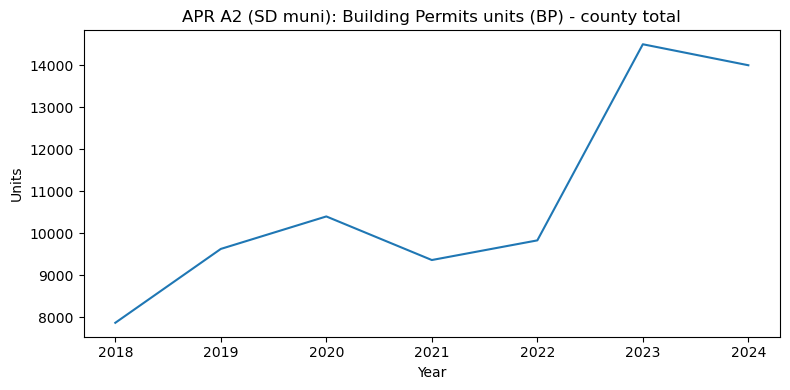

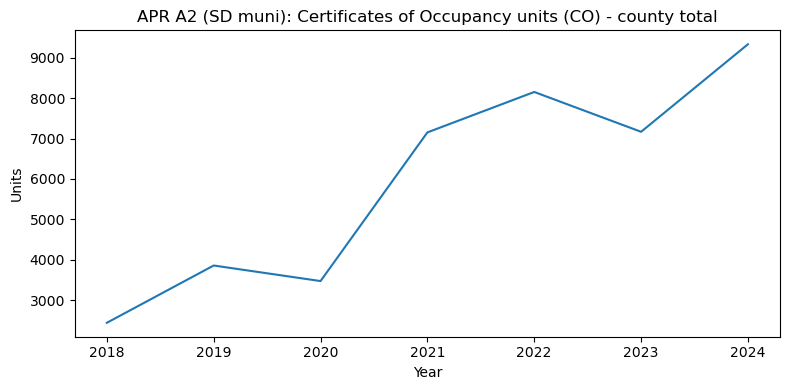

,year,bp_units,co_units
0,2018,7874.0,2440.0
1,2019,9630.0,3858.0
2,2020,10402.0,3473.0
3,2021,9366.0,7153.0
4,2022,9833.0,8154.0
5,2023,14495.0,7168.0
6,2024,13996.0,9335.0


In [141]:
ensure_cols(apr_city_year_sd, ["jur_clean","year","bp_units_total","co_units_total","bp_affordable_share","co_affordable_share"])

apr_ts = apr_city_year_sd.copy()
apr_ts["jur_norm"] = apr_ts["jur_clean"].map(clean_city_name)
apr_ts["year"] = pd.to_numeric(apr_ts["year"], errors="coerce")

county_totals = (apr_ts.groupby("year", as_index=False)
                 .agg(bp_units=("bp_units_total","sum"),
                      co_units=("co_units_total","sum")))

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(county_totals["year"], county_totals["bp_units"])
ax.set_title("APR A2 (SD muni): Building Permits units (BP) - county total")
ax.set_xlabel("Year"); ax.set_ylabel("Units")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(county_totals["year"], county_totals["co_units"])
ax.set_title("APR A2 (SD muni): Certificates of Occupancy units (CO) - county total")
ax.set_xlabel("Year"); ax.set_ylabel("Units")
plt.tight_layout(); plt.show()

display(county_totals.tail(10))

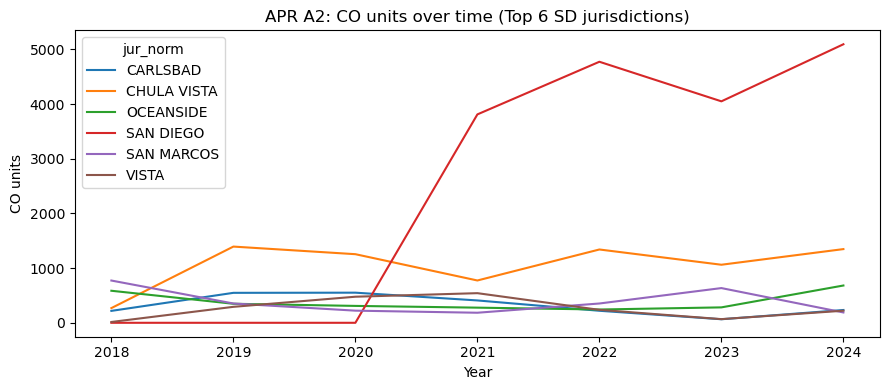

Top 10 SD jurisdictions by total CO units (APR A2)


jur_norm
SAN DIEGO      17733.0
CHULA VISTA     7443.0
OCEANSIDE       2727.0
SAN MARCOS      2709.0
CARLSBAD        2245.0
VISTA           1851.0
ESCONDIDO       1657.0
ENCINITAS        951.0
SANTEE           761.0
POWAY            704.0
Name: co_units_total, dtype: float64

jur_norm
SAN DIEGO      17733.0
CHULA VISTA     7443.0
OCEANSIDE       2727.0
SAN MARCOS      2709.0
CARLSBAD        2245.0
VISTA           1851.0
ESCONDIDO       1657.0
ENCINITAS        951.0
SANTEE           761.0
POWAY            704.0
Name: co_units_total, dtype: float64

In [142]:
top = (apr_ts.groupby("jur_norm")["co_units_total"].sum()
       .sort_values(ascending=False).head(6).index.tolist())

tmp = (apr_ts[apr_ts["jur_norm"].isin(top)]
       .pivot_table(index="year", columns="jur_norm", values="co_units_total", aggfunc="sum")
       .fillna(0))

fig, ax = plt.subplots(figsize=(9,4))
tmp.plot(ax=ax)
ax.set_title("APR A2: CO units over time (Top 6 SD jurisdictions)")
ax.set_xlabel("Year"); ax.set_ylabel("CO units")
plt.tight_layout(); plt.show()

show_top(apr_ts, "co_units_total", n=10, title="Top 10 SD jurisdictions by total CO units (APR A2)")

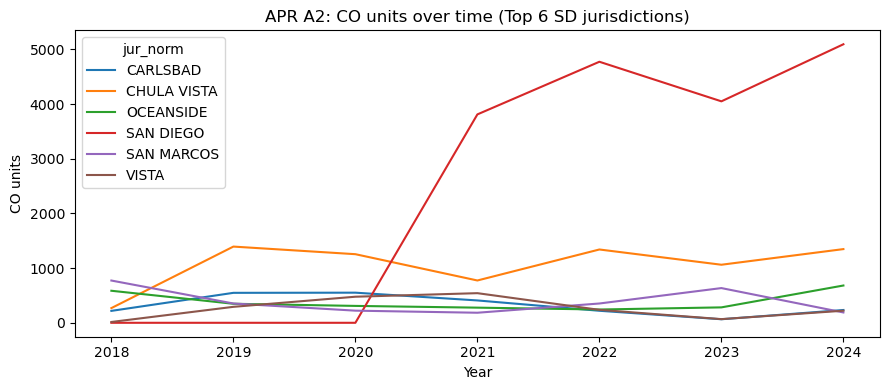

Top 10 SD jurisdictions by total CO units (APR A2)


jur_norm
SAN DIEGO      17733.0
CHULA VISTA     7443.0
OCEANSIDE       2727.0
SAN MARCOS      2709.0
CARLSBAD        2245.0
VISTA           1851.0
ESCONDIDO       1657.0
ENCINITAS        951.0
SANTEE           761.0
POWAY            704.0
Name: co_units_total, dtype: float64

jur_norm
SAN DIEGO      17733.0
CHULA VISTA     7443.0
OCEANSIDE       2727.0
SAN MARCOS      2709.0
CARLSBAD        2245.0
VISTA           1851.0
ESCONDIDO       1657.0
ENCINITAS        951.0
SANTEE           761.0
POWAY            704.0
Name: co_units_total, dtype: float64

In [143]:
top = (apr_ts.groupby("jur_norm")["co_units_total"].sum()
       .sort_values(ascending=False).head(6).index.tolist())

tmp = (apr_ts[apr_ts["jur_norm"].isin(top)]
       .pivot_table(index="year", columns="jur_norm", values="co_units_total", aggfunc="sum")
       .fillna(0))

fig, ax = plt.subplots(figsize=(9,4))
tmp.plot(ax=ax)
ax.set_title("APR A2: CO units over time (Top 6 SD jurisdictions)")
ax.set_xlabel("Year"); ax.set_ylabel("CO units")
plt.tight_layout(); plt.show()

show_top(apr_ts, "co_units_total", n=10, title="Top 10 SD jurisdictions by total CO units (APR A2)")

In [144]:
ensure_cols(rhna6, ["Jurisdiction","VLI UNITS","RHNA VLI","LI UNITS","RHNA LI","MOD UNITS","RHNA MOD","ABOVE MOD UNITS","RHNA ABOVE MOD"])

rh = rhna6.copy()
rh["jur_norm"] = rh["Jurisdiction"].map(clean_city_name)

sd_norm = set(clean_city_name(x) for x in sd_muni_names)
rh_sd = rh[rh["jur_norm"].isin(sd_norm)].copy()

for c in ["VLI UNITS","RHNA VLI","LI UNITS","RHNA LI","MOD UNITS","RHNA MOD","ABOVE MOD UNITS","RHNA ABOVE MOD"]:
    rh_sd[c] = pd.to_numeric(rh_sd[c], errors="coerce")

rh_sd["units_reported_total"] = rh_sd[["VLI UNITS","LI UNITS","MOD UNITS","ABOVE MOD UNITS"]].sum(axis=1)
rh_sd["rhna_target_total"] = rh_sd[["RHNA VLI","RHNA LI","RHNA MOD","RHNA ABOVE MOD"]].sum(axis=1)
rh_sd["pct_achieved_total"] = np.where(rh_sd["rhna_target_total"] > 0,
                                       rh_sd["units_reported_total"]/rh_sd["rhna_target_total"], np.nan)

display(rh_sd[["jur_norm","units_reported_total","rhna_target_total","pct_achieved_total"]]
        .sort_values("pct_achieved_total", ascending=False))

,jur_norm,units_reported_total,rhna_target_total,pct_achieved_total
194,ENCINITAS,1264,1554,0.813385
55,DEL MAR,97,163,0.595092
456,SAN MARCOS,1798,3116,0.577022
139,CHULA VISTA,5453,11105,0.491040
368,OCEANSIDE,2168,5443,0.398310
428,SANTEE,477,1219,0.391304
335,POWAY,440,1319,0.333586
54,CARLSBAD,1204,3873,0.310870
461,VISTA,717,2561,0.279969
302,SAN DIEGO,28903,108036,0.267531


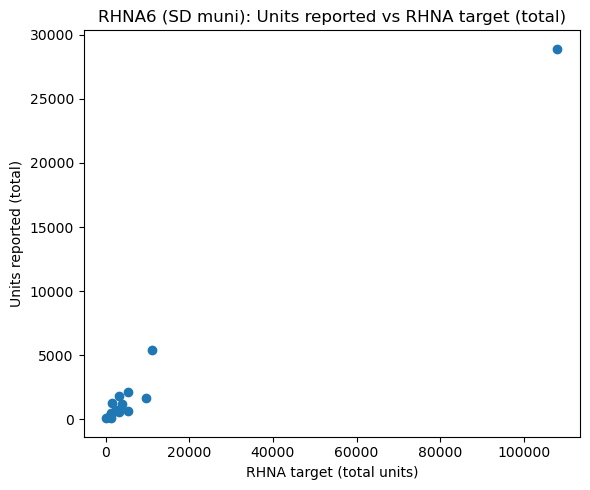

/var/folders/dg/bllrnyzj2fzf93_myxywvnnm0000gn/T/ipykernel_55365/1864916686.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rh_plot["jur_norm"], rotation=70, ha="right")


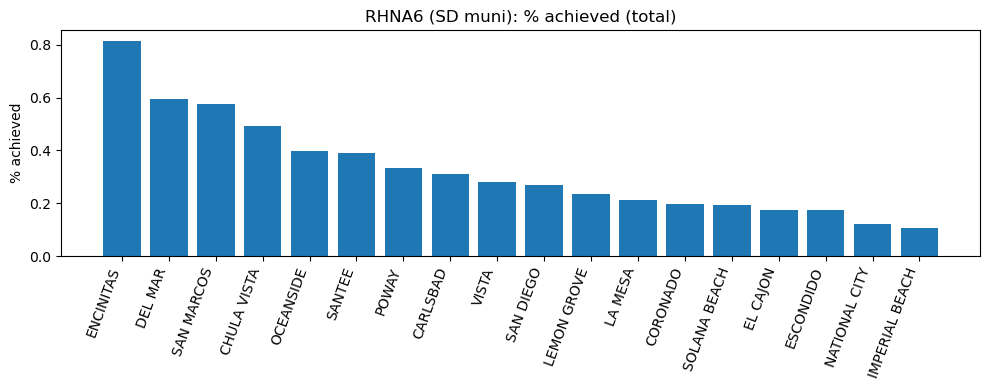

In [145]:
fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(rh_sd["rhna_target_total"], rh_sd["units_reported_total"])
ax.set_title("RHNA6 (SD muni): Units reported vs RHNA target (total)")
ax.set_xlabel("RHNA target (total units)")
ax.set_ylabel("Units reported (total)")
plt.tight_layout(); plt.show()

rh_plot = rh_sd.sort_values("pct_achieved_total", ascending=False)

fig, ax = plt.subplots(figsize=(10,4))
ax.bar(rh_plot["jur_norm"], rh_plot["pct_achieved_total"])
ax.set_title("RHNA6 (SD muni): % achieved (total)")
ax.set_ylabel("% achieved")
ax.set_xticklabels(rh_plot["jur_norm"], rotation=70, ha="right")
plt.tight_layout(); plt.show()

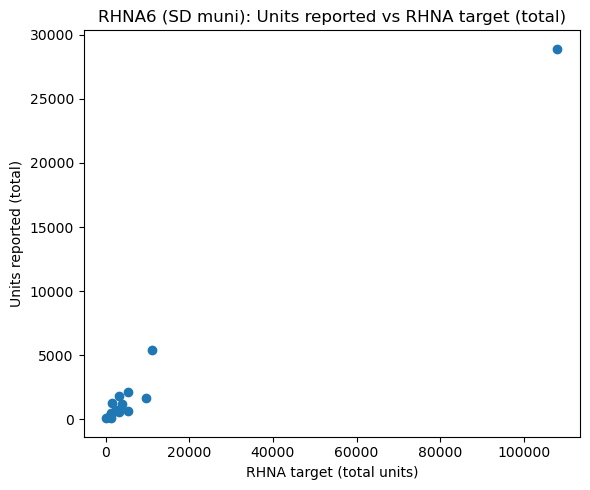

/var/folders/dg/bllrnyzj2fzf93_myxywvnnm0000gn/T/ipykernel_55365/1864916686.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rh_plot["jur_norm"], rotation=70, ha="right")


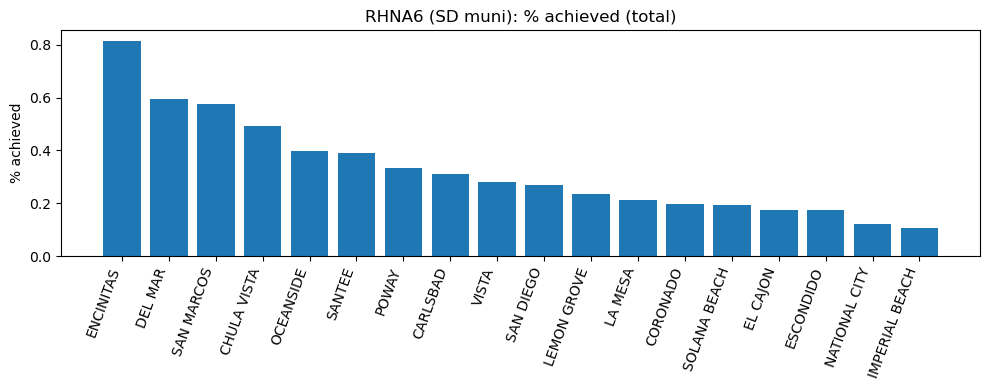

In [146]:
fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(rh_sd["rhna_target_total"], rh_sd["units_reported_total"])
ax.set_title("RHNA6 (SD muni): Units reported vs RHNA target (total)")
ax.set_xlabel("RHNA target (total units)")
ax.set_ylabel("Units reported (total)")
plt.tight_layout(); plt.show()

rh_plot = rh_sd.sort_values("pct_achieved_total", ascending=False)

fig, ax = plt.subplots(figsize=(10,4))
ax.bar(rh_plot["jur_norm"], rh_plot["pct_achieved_total"])
ax.set_title("RHNA6 (SD muni): % achieved (total)")
ax.set_ylabel("% achieved")
ax.set_xticklabels(rh_plot["jur_norm"], rotation=70, ha="right")
plt.tight_layout(); plt.show()

In [147]:
permits = pd.concat(
    [permits_active.assign(status="active"), permits_closed.assign(status="closed")],
    ignore_index=True
)

permits["issue_date"] = pd.to_datetime(permits["DATE_APPROVAL_ISSUE"], errors="coerce")
permits["issue_year"] = permits["issue_date"].dt.year

du_cols = [
    "APPROVAL_DU_EXTREMELY_LOW","APPROVAL_DU_VERY_LOW","APPROVAL_DU_LOW",
    "APPROVAL_DU_MODERATE","APPROVAL_DU_ABOVE_MODERATE","APPROVAL_DU_BONUS"
]
for c in du_cols + ["APPROVAL_ADU_TOTAL","APPROVAL_JADU_TOTAL"]:
    permits[c] = pd.to_numeric(permits[c], errors="coerce")

permits["du_total"] = permits[du_cols].sum(axis=1, min_count=1)

housing_like = permits[
    permits["issue_year"].notna() &
    (
        permits["du_total"].notna() |
        permits["APPROVAL_ADU_TOTAL"].notna() |
        permits["APPROVAL_JADU_TOTAL"].notna()
    )
].copy()

by_year = (housing_like.groupby("issue_year", as_index=False)
           .agg(
               permits=("APPROVAL_ID","count"),
               du_total=("du_total","sum"),
               adu_total=("APPROVAL_ADU_TOTAL","sum"),
               jadu_total=("APPROVAL_JADU_TOTAL","sum"),
           ))

display(by_year.tail(20))

,issue_year,permits,du_total,adu_total,jadu_total
0,2021.0,144,-68.0,0.0,0.0
1,2022.0,2435,584.0,31.0,5.0
2,2023.0,6454,7382.0,1372.0,169.0
3,2024.0,6501,9708.0,1708.0,168.0
4,2025.0,5319,7804.0,1743.0,85.0
5,2026.0,1241,2000.0,409.0,16.0


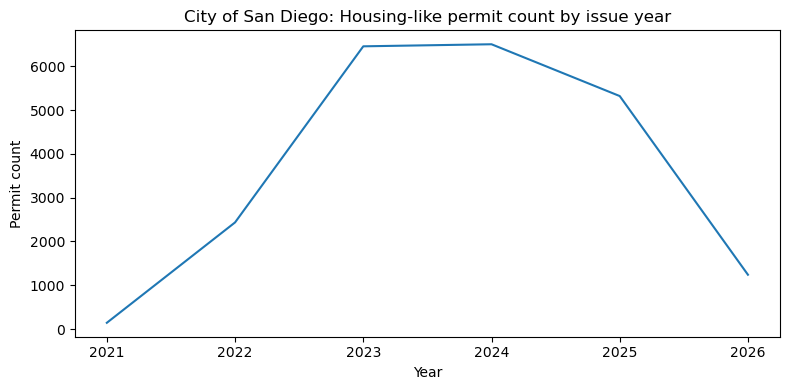

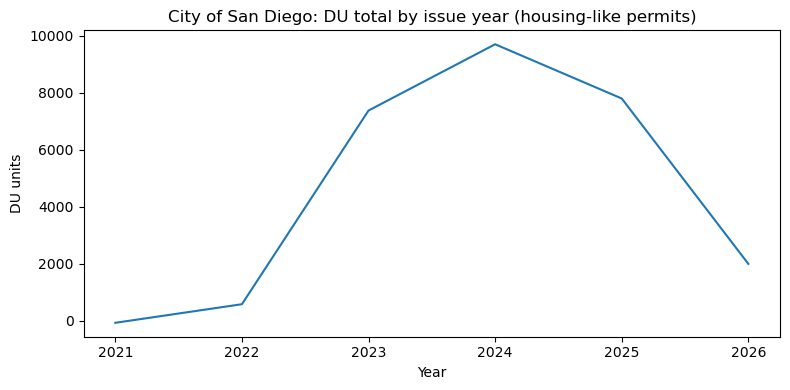

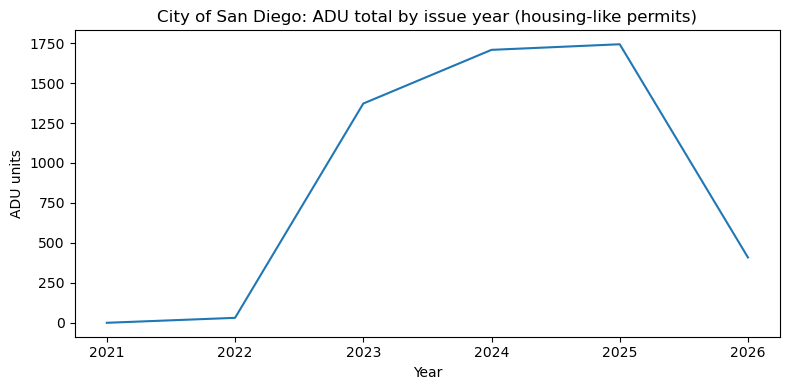

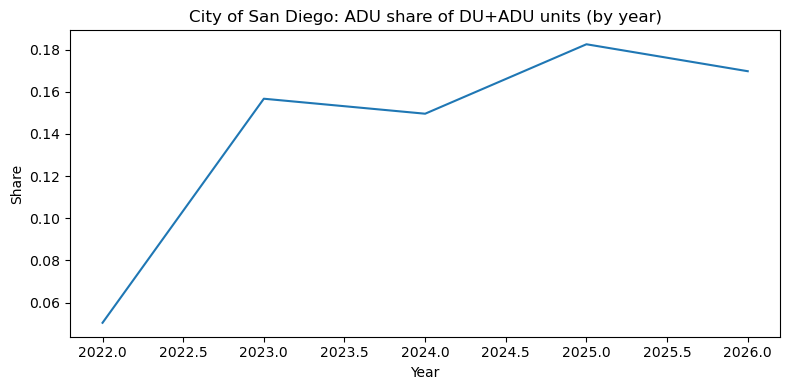

In [148]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(by_year["issue_year"], by_year["permits"])
ax.set_title("City of San Diego: Housing-like permit count by issue year")
ax.set_xlabel("Year"); ax.set_ylabel("Permit count")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(by_year["issue_year"], by_year["du_total"])
ax.set_title("City of San Diego: DU total by issue year (housing-like permits)")
ax.set_xlabel("Year"); ax.set_ylabel("DU units")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(by_year["issue_year"], by_year["adu_total"])
ax.set_title("City of San Diego: ADU total by issue year (housing-like permits)")
ax.set_xlabel("Year"); ax.set_ylabel("ADU units")
plt.tight_layout(); plt.show()

by_year["adu_share_units"] = np.where((by_year["du_total"] + by_year["adu_total"]) > 0,
                                      by_year["adu_total"] / (by_year["du_total"] + by_year["adu_total"]), np.nan)

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(by_year["issue_year"], by_year["adu_share_units"])
ax.set_title("City of San Diego: ADU share of DU+ADU units (by year)")
ax.set_xlabel("Year"); ax.set_ylabel("Share")
plt.tight_layout(); plt.show()

,jur_norm,population,median_household_income,median_gross_rent,pct_renter
364,DEL MAR,3921,192845,3377,0.457143
315,CORONADO,18558,135056,3250,0.454285
1361,SOLANA BEACH,12841,150820,3022,0.316186
469,ENCINITAS,61585,150471,2730,0.336309
218,CARLSBAD,114500,139326,2678,0.366681
1160,POWAY,48515,143825,2261,0.243309
1266,SAN DIEGO,1385061,104321,2223,0.524281
1041,OCEANSIDE,172542,93724,2207,0.415357
1310,SANTEE,59485,105613,2197,0.280510
1283,SAN MARCOS,94078,105286,2191,0.369527


/var/folders/dg/bllrnyzj2fzf93_myxywvnnm0000gn/T/ipykernel_55365/2841484780.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(acs_sd.sort_values("median_gross_rent")["jur_norm"], rotation=70, ha="right")


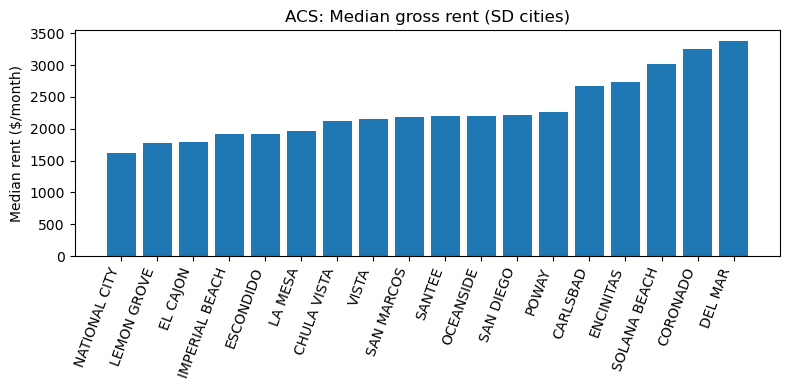

/var/folders/dg/bllrnyzj2fzf93_myxywvnnm0000gn/T/ipykernel_55365/2841484780.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(acs_sd.sort_values("pct_renter")["jur_norm"], rotation=70, ha="right")


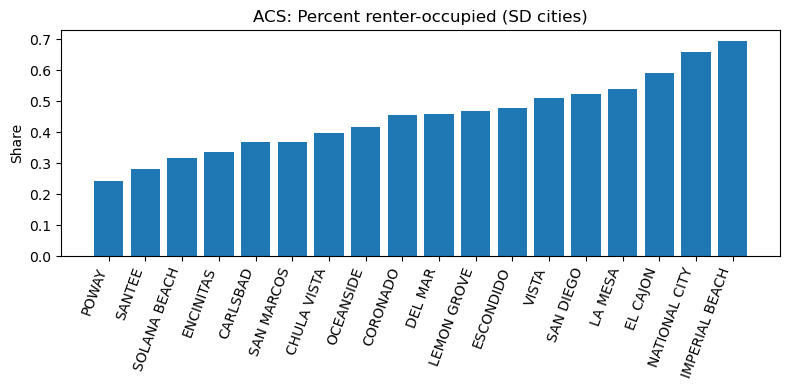

In [149]:
acs_sd = acs_sd_fixed.copy()

display(acs_sd[["jur_norm","population","median_household_income","median_gross_rent","pct_renter"]]
        .sort_values("median_gross_rent", ascending=False))

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(acs_sd.sort_values("median_gross_rent")["jur_norm"],
       acs_sd.sort_values("median_gross_rent")["median_gross_rent"])
ax.set_title("ACS: Median gross rent (SD cities)")
ax.set_ylabel("Median rent ($/month)")
ax.set_xticklabels(acs_sd.sort_values("median_gross_rent")["jur_norm"], rotation=70, ha="right")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(acs_sd.sort_values("pct_renter")["jur_norm"],
       acs_sd.sort_values("pct_renter")["pct_renter"])
ax.set_title("ACS: Percent renter-occupied (SD cities)")
ax.set_ylabel("Share")
ax.set_xticklabels(acs_sd.sort_values("pct_renter")["jur_norm"], rotation=70, ha="right")
plt.tight_layout(); plt.show()

,jur_norm,population_total,housing_units_total,housing_units_per_1000_pop
77,SAN DIEGO,1408937.0,581050.0,412.403110
11,CHULA VISTA,281401.0,91485.0,325.105454
65,OCEANSIDE,174340.0,69097.0,396.334748
41,ESCONDIDO,150425.0,50883.0,338.261592
5,CARLSBAD,116368.0,48888.0,420.115496
29,EL CAJON,104932.0,37011.0,352.714139
101,VISTA,101599.0,34384.0,338.428528
83,SAN MARCOS,97123.0,33157.0,341.391843
35,ENCINITAS,61956.0,27118.0,437.697721
53,LA MESA,60908.0,26851.0,440.845209


/var/folders/dg/bllrnyzj2fzf93_myxywvnnm0000gn/T/ipykernel_55365/4099261075.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(dof_latest.sort_values("housing_units_per_1000_pop")["jur_norm"], rotation=70, ha="right")


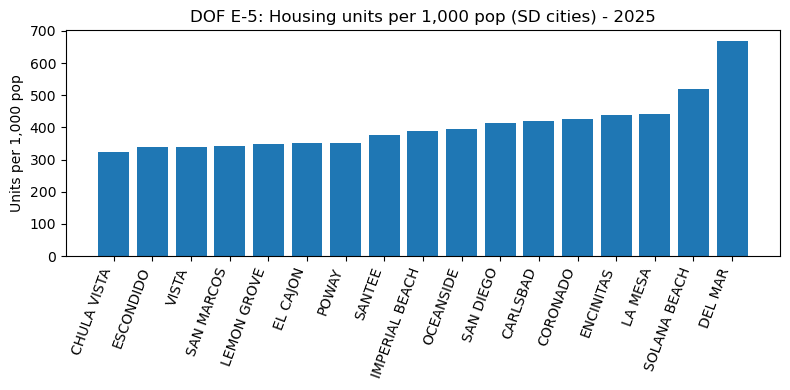

In [150]:
dof = dof_city_year.copy()

if "jur_norm" not in dof.columns:
    if "jur_clean" in dof.columns:
        dof["jur_norm"] = dof["jur_clean"].map(clean_city_name)
    elif "city" in dof.columns:
        dof["jur_norm"] = dof["city"].map(clean_city_name)

dof["year"] = pd.to_numeric(dof["year"], errors="coerce")
dof["housing_units_total"] = pd.to_numeric(dof["housing_units_total"], errors="coerce")
dof["population_total"] = pd.to_numeric(dof["population_total"], errors="coerce")

sd_norm = set(clean_city_name(x) for x in sd_muni_names)
dof_sd = dof[dof["jur_norm"].isin(sd_norm)].copy()

dof_sd["housing_units_per_1000_pop"] = 1000 * dof_sd["housing_units_total"] / dof_sd["population_total"]

latest = int(dof_sd["year"].max())
dof_latest = dof_sd[dof_sd["year"] == latest].copy()

display(dof_latest[["jur_norm","population_total","housing_units_total","housing_units_per_1000_pop"]]
        .sort_values("housing_units_total", ascending=False))

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(dof_latest.sort_values("housing_units_per_1000_pop")["jur_norm"],
       dof_latest.sort_values("housing_units_per_1000_pop")["housing_units_per_1000_pop"])
ax.set_title(f"DOF E-5: Housing units per 1,000 pop (SD cities) - {latest}")
ax.set_ylabel("Units per 1,000 pop")
ax.set_xticklabels(dof_latest.sort_values("housing_units_per_1000_pop")["jur_norm"], rotation=70, ha="right")
plt.tight_layout(); plt.show()

In [151]:
apr_latest_year = int(apr_ts["year"].max())
apr_latest = apr_ts[apr_ts["year"] == apr_latest_year].copy()

rh_sd_small = rh_sd[["jur_norm","rhna_target_total","units_reported_total","pct_achieved_total"]].copy()

acs_small = acs_sd_fixed[["jur_norm","population","median_household_income","median_gross_rent","pct_renter"]].copy()

dof_latest_small = dof_latest[["jur_norm","housing_units_total","housing_units_per_1000_pop"]].copy()

kpi_city = (apr_latest[["jur_norm","bp_units_total","co_units_total","bp_affordable_share","co_affordable_share"]]
            .merge(acs_small, on="jur_norm", how="left")
            .merge(dof_latest_small, on="jur_norm", how="left")
            .merge(rh_sd_small, on="jur_norm", how="left"))

kpi_city["co_units_per_10k_pop"] = 10000 * kpi_city["co_units_total"] / kpi_city["population"]

display(kpi_city.sort_values("co_units_per_10k_pop", ascending=False))

kpi_city.to_csv(DATA_PROCESSED / "sd_kpi_city_scorecard.csv", index=False)
print("Wrote:", DATA_PROCESSED / "sd_kpi_city_scorecard.csv")

,jur_norm,bp_units_total,co_units_total,bp_affordable_share,co_affordable_share,population,median_household_income,median_gross_rent,pct_renter,housing_units_total,housing_units_per_1000_pop,rhna_target_total,units_reported_total,pct_achieved_total,co_units_per_10k_pop
9,LEMON GROVE,65.0,160.0,0.061538,0.062500,27489,79278,1769,0.466872,9812.0,348.400383,1359,317,0.233260,58.205100
12,POWAY,63.0,281.0,0.000000,0.003559,48515,143825,2261,0.243309,17773.0,352.785883,1319,440,0.333586,57.920231
3,DEL MAR,20.0,21.0,0.550000,0.571429,3921,192845,3377,0.457143,2641.0,668.607595,163,97,0.595092,53.557766
1,CHULA VISTA,1643.0,1348.0,0.033475,0.189169,275030,105173,2122,0.398260,91485.0,325.105454,11105,5453,0.491040,49.012835
10,NATIONAL CITY,204.0,272.0,0.612745,0.536765,55960,64248,1619,0.657574,NaN,NaN,5437,658,0.121023,48.606147
5,ENCINITAS,695.0,258.0,0.174101,0.186047,61585,150471,2730,0.336309,27118.0,437.697721,1554,1264,0.813385,41.893318
11,OCEANSIDE,595.0,682.0,0.337815,0.321114,172542,93724,2207,0.415357,69097.0,396.334748,5443,2168,0.398310,39.526608
13,SAN DIEGO,8782.0,5095.0,0.120815,0.136408,1385061,104321,2223,0.524281,581050.0,412.403110,108036,28903,0.267531,36.785383
2,CORONADO,40.0,42.0,0.000000,0.000000,18558,135056,3250,0.454285,9646.0,426.625387,912,180,0.197368,22.631749
17,VISTA,218.0,221.0,0.000000,0.244344,98646,91854,2148,0.508381,34384.0,338.428528,2561,717,0.279969,22.403341


Wrote: ../data/processed/sd_kpi_city_scorecard.csv


In [153]:
print("Suggested KPI fields to consider (city-level):")
candidates = [
    ("Housing production (CO units)", "co_units_total"),
    ("Housing production (BP units)", "bp_units_total"),
    ("CO affordable share", "co_affordable_share"),
    ("CO units per 10k pop", "co_units_per_10k_pop"),
    ("RHNA % achieved (total)", "pct_achieved_total"),
    ("Median gross rent", "median_gross_rent"),
    ("Median household income", "median_household_income"),
    ("% renter", "pct_renter"),
    ("Housing units per 1k pop (stock)", "housing_units_per_1000_pop"),
]

for label, col in candidates:
    if col in kpi_city.columns:
        top5 = kpi_city[["jur_norm", col]].sort_values(col, ascending=False).head(5)
        print("\n", label, f"({col}) top 5")
        display(top5)

Suggested KPI fields to consider (city-level):

 Housing production (CO units) (co_units_total) top 5


,jur_norm,co_units_total
13,SAN DIEGO,5095.0
1,CHULA VISTA,1348.0
11,OCEANSIDE,682.0
12,POWAY,281.0
10,NATIONAL CITY,272.0



 Housing production (BP units) (bp_units_total) top 5


,jur_norm,bp_units_total
13,SAN DIEGO,8782.0
1,CHULA VISTA,1643.0
5,ENCINITAS,695.0
11,OCEANSIDE,595.0
6,ESCONDIDO,408.0



 CO affordable share (co_affordable_share) top 5


...

,jur_norm,median_household_income
3,DEL MAR,192845
16,SOLANA BEACH,150820
5,ENCINITAS,150471
12,POWAY,143825
0,CARLSBAD,139326



 % renter (pct_renter) top 5


,jur_norm,pct_renter
7,IMPERIAL BEACH,0.693382
10,NATIONAL CITY,0.657574
4,EL CAJON,0.589096
8,LA MESA,0.540035
13,SAN DIEGO,0.524281



 Housing units per 1k pop (stock) (housing_units_per_1000_pop) top 5


,jur_norm,housing_units_per_1000_pop
3,DEL MAR,668.607595
16,SOLANA BEACH,518.712460
8,LA MESA,440.845209
5,ENCINITAS,437.697721
2,CORONADO,426.625387


In [155]:
dof_found = set(dof_city_year["jur_norm"].dropna().unique())
print(sorted(sd_norm - dof_found))

['NATIONAL CITY']


In [158]:
# final clean run cell
# assumes earlier cells already defined/imported:
# - DATA_PROCESSED
# - clean_city_name(), profile_df(), find_first_file()
# - apr_a2, rhna6
# - pandas as pd, numpy as np, requests, re
sd_muni_names = [
    "CARLSBAD", "CHULA VISTA", "CORONADO", "DEL MAR", "EL CAJON", "ENCINITAS",
    "ESCONDIDO", "IMPERIAL BEACH", "LA MESA", "LEMON GROVE", "NATIONAL CITY",
    "OCEANSIDE", "POWAY", "SAN DIEGO", "SAN MARCOS", "SANTEE",
    "SOLANA BEACH", "VISTA"
]
sd_norm = set(clean_city_name(x) for x in sd_muni_names)

apr = apr_a2.copy()
apr["CNTY_NAME"] = apr["CNTY_NAME"].astype(str).str.strip()
apr["jur_clean"] = apr["JURIS_NAME"].map(clean_city_name)

apr_sd = apr[
    (apr["CNTY_NAME"] == "San Diego") &
    (apr["jur_clean"].isin(sd_norm))
].copy()

apr_sd["YEAR"] = pd.to_numeric(apr_sd["YEAR"], errors="coerce")

bp_cols = [
    "BP_VLOW_INCOME_DR", "BP_VLOW_INCOME_NDR",
    "BP_LOW_INCOME_DR", "BP_LOW_INCOME_NDR",
    "BP_MOD_INCOME_DR", "BP_MOD_INCOME_NDR",
    "BP_ABOVE_MOD_INCOME"
]
co_cols = [
    "CO_VLOW_INCOME_DR", "CO_VLOW_INCOME_NDR",
    "CO_LOW_INCOME_DR", "CO_LOW_INCOME_NDR",
    "CO_MOD_INCOME_DR", "CO_MOD_INCOME_NDR",
    "CO_ABOVE_MOD_INCOME"
]

for c in bp_cols + co_cols:
    apr_sd[c] = pd.to_numeric(apr_sd[c], errors="coerce").fillna(0)

apr_ts = (
    apr_sd.dropna(subset=["jur_clean", "YEAR"])
    .groupby(["jur_clean", "YEAR"], as_index=False)[bp_cols + co_cols]
    .sum()
    .rename(columns={"YEAR": "year"})
)

apr_ts["jur_norm"] = apr_ts["jur_clean"].map(clean_city_name)
apr_ts["bp_units_total"] = apr_ts[bp_cols].sum(axis=1)
apr_ts["co_units_total"] = apr_ts[co_cols].sum(axis=1)

bp_aff_cols = bp_cols[:-1]
co_aff_cols = co_cols[:-1]

apr_ts["bp_affordable_total"] = apr_ts[bp_aff_cols].sum(axis=1)
apr_ts["co_affordable_total"] = apr_ts[co_aff_cols].sum(axis=1)

apr_ts["bp_affordable_share"] = np.where(
    apr_ts["bp_units_total"] > 0,
    apr_ts["bp_affordable_total"] / apr_ts["bp_units_total"],
    np.nan
)
apr_ts["co_affordable_share"] = np.where(
    apr_ts["co_units_total"] > 0,
    apr_ts["co_affordable_total"] / apr_ts["co_units_total"],
    np.nan
)

apr_ts.to_csv(DATA_PROCESSED / "sd_apr_a2_city_year_supply.csv", index=False)
profile_df(apr_ts, "APR A2 SD: city-year totals (final)")

ACS_YEAR = "2023"
ACS_DATASET = "acs/acs5"
STATEFP_CA = "06"

ACS_VARS = {
    "B01003_001E": "population",
    "B11001_001E": "households",
    "B25003_001E": "housing_occupied",
    "B25003_002E": "owner_occupied",
    "B25003_003E": "renter_occupied",
    "B19013_001E": "median_household_income",
    "B25064_001E": "median_gross_rent",
    "B25077_001E": "median_home_value",
}

acs_url = f"https://api.census.gov/data/{ACS_YEAR}/{ACS_DATASET}"
acs_params = {
    "get": ",".join(["NAME"] + list(ACS_VARS.keys())),
    "for": "place:*",
    "in": f"state:{STATEFP_CA}",
}

resp = requests.get(acs_url, params=acs_params, timeout=60)
resp.raise_for_status()

acs_raw = resp.json()
acs = pd.DataFrame(acs_raw[1:], columns=acs_raw[0]).rename(columns=ACS_VARS)

for c in ACS_VARS.values():
    acs[c] = pd.to_numeric(acs[c], errors="coerce")

acs["place_geoid"] = acs["state"] + acs["place"]

acs["city_only"] = acs["NAME"].astype(str).str.split(",").str[0]
acs["city_only"] = acs["city_only"].str.replace(r"\s+city$", "", regex=True, case=False)
acs["city_only"] = acs["city_only"].str.replace(r"\s+town$", "", regex=True, case=False)
acs["city_only"] = acs["city_only"].str.replace(r"\s+village$", "", regex=True, case=False)
acs["jur_norm"] = acs["city_only"].map(clean_city_name)

acs_sd_fixed = acs[acs["jur_norm"].isin(sd_norm)].copy()
acs_sd_fixed["pct_renter"] = acs_sd_fixed["renter_occupied"] / acs_sd_fixed["housing_occupied"]
acs_sd_fixed["pct_owner"] = acs_sd_fixed["owner_occupied"] / acs_sd_fixed["housing_occupied"]

print("ACS SD rows:", len(acs_sd_fixed))
assert len(acs_sd_fixed) == 18, f"Expected 18 ACS rows, got {len(acs_sd_fixed)}"
assert acs_sd_fixed["jur_norm"].nunique() == 18, "ACS cities are not unique"

acs_sd_fixed.to_csv(DATA_PROCESSED / f"sd_acs_place_{ACS_YEAR}_summary_fixed.csv", index=False)
profile_df(acs_sd_fixed, f"ACS {ACS_YEAR} Place Summary (SD muni, fixed)")

dof_path = find_first_file(["*E-5*Geo*InternetVersion*.xls*", "*E*5*Geo*InternetVersion*.xlsx"])
if dof_path is None:
    raise FileNotFoundError("Could not find DOF E-5 file in data/raw")

raw = pd.read_excel(dof_path, sheet_name="E-5 by Geography", header=None)

def row_has_headers(r):
    vals = [str(x).strip().lower() for x in r.values if pd.notna(x)]
    return ("county" in vals) and ("city" in vals) and ("date" in vals)

header_row_idx = None
for i in range(min(40, len(raw))):
    if row_has_headers(raw.iloc[i]):
        header_row_idx = i
        break

if header_row_idx is None:
    raise ValueError("Could not find DOF header row")

new_cols = raw.iloc[header_row_idx].tolist()
dof = raw.iloc[header_row_idx + 1:].copy()
dof.columns = [str(c).strip() for c in new_cols]
dof = dof.dropna(axis=1, how="all")

cols = dof.columns.tolist()
total_idxs = [i for i, c in enumerate(cols) if str(c).strip().lower() == "total"]
if len(total_idxs) >= 2:
    cols[total_idxs[0]] = "population_total"
    cols[total_idxs[1]] = "housing_units_total"
    dof.columns = cols
elif len(total_idxs) == 1:
    cols[total_idxs[0]] = "population_total"
    dof.columns = cols

dof = dof.rename(columns={
    "County": "county",
    "City": "city",
    "Date": "date",
    "Household": "population_household",
    "Group Quarters": "population_group_quarters",
    "Single Detached": "housing_single_detached",
    "Single Attached": "housing_single_attached",
    "Two to Four": "housing_2to4",
    "Five Plus": "housing_5plus",
})

dof["date"] = pd.to_datetime(dof["date"], errors="coerce")
dof["year"] = dof["date"].dt.year

for c in ["population_total", "housing_units_total"]:
    if c in dof.columns:
        dof[c] = pd.to_numeric(dof[c], errors="coerce")

def clean_dof_city(x):
    if pd.isna(x):
        return x
    x = str(x).strip()
    x = re.sub(r"\s+City$", "", x, flags=re.IGNORECASE)
    return clean_city_name(x)

dof["jur_norm"] = dof["city"].map(clean_dof_city)
dof_sd = dof[dof["jur_norm"].isin(sd_norm)].copy()

dof_city_year = (
    dof_sd.dropna(subset=["jur_norm", "year"])
    .groupby(["jur_norm", "year"], as_index=False)
    .agg(
        population_total=("population_total", "sum"),
        housing_units_total=("housing_units_total", "sum"),
    )
)

dof_city_year["housing_units_per_1000_pop"] = (
    1000 * dof_city_year["housing_units_total"] / dof_city_year["population_total"]
)

dof_found = set(dof_city_year["jur_norm"].dropna().unique())
missing_dof = sorted(sd_norm - dof_found)

print(f"DOF municipalities found: {len(dof_found)}")
print("Missing from DOF:", missing_dof)

assert len(dof_found) >= 17, f"Unexpectedly low DOF coverage: only {len(dof_found)} municipalities found"

dof_city_year.to_csv(DATA_PROCESSED / "sd_dof_e5_city_year.csv", index=False)
profile_df(dof_city_year, "DOF E-5 SD: city-year population + housing units")

rh = rhna6.copy()
rh["jur_norm"] = rh["Jurisdiction"].map(clean_city_name)
rh_sd = rh[rh["jur_norm"].isin(sd_norm)].copy()

rhna_num_cols = [
    "VLI UNITS", "RHNA VLI",
    "LI UNITS", "RHNA LI",
    "MOD UNITS", "RHNA MOD",
    "ABOVE MOD UNITS", "RHNA ABOVE MOD"
]

for c in rhna_num_cols:
    rh_sd[c] = pd.to_numeric(rh_sd[c], errors="coerce")

rh_sd["units_reported_total"] = rh_sd[
    ["VLI UNITS", "LI UNITS", "MOD UNITS", "ABOVE MOD UNITS"]
].sum(axis=1)

rh_sd["rhna_target_total"] = rh_sd[
    ["RHNA VLI", "RHNA LI", "RHNA MOD", "RHNA ABOVE MOD"]
].sum(axis=1)

rh_sd["pct_achieved_total"] = np.where(
    rh_sd["rhna_target_total"] > 0,
    rh_sd["units_reported_total"] / rh_sd["rhna_target_total"],
    np.nan
)

assert rh_sd["jur_norm"].nunique() == 18, "RHNA does not cover all 18 SD municipalities"

rh_sd.to_csv(DATA_PROCESSED / "sd_rhna6_city_totals.csv", index=False)
profile_df(rh_sd, "RHNA6 SD: totals")

apr_latest_year = int(apr_ts["year"].max())
apr_latest = apr_ts[apr_ts["year"] == apr_latest_year].copy()

dof_latest_year = int(dof_city_year["year"].max())
dof_latest = dof_city_year[dof_city_year["year"] == dof_latest_year].copy()

acs_small = acs_sd_fixed[
    ["jur_norm", "population", "median_household_income", "median_gross_rent", "pct_renter"]
].copy()

dof_latest_small = dof_latest[
    ["jur_norm", "population_total", "housing_units_total", "housing_units_per_1000_pop"]
].copy()

rh_small = rh_sd[
    ["jur_norm", "rhna_target_total", "units_reported_total", "pct_achieved_total"]
].copy()

kpi_city = (
    apr_latest[
        [
            "jur_norm",
            "bp_units_total", "co_units_total",
            "bp_affordable_total", "co_affordable_total",
            "bp_affordable_share", "co_affordable_share"
        ]
    ]
    .merge(acs_small, on="jur_norm", how="left")
    .merge(dof_latest_small, on="jur_norm", how="left")
    .merge(rh_small, on="jur_norm", how="left")
)

kpi_city["co_units_per_10k_pop"] = 10000 * kpi_city["co_units_total"] / kpi_city["population"]

assert len(kpi_city) == 18, f"Expected 18 rows in final KPI table, got {len(kpi_city)}"
assert kpi_city["jur_norm"].nunique() == 18, "Duplicate city rows in final KPI table"
assert kpi_city["population"].notna().all(), "ACS merge failed for some cities"
assert kpi_city["rhna_target_total"].notna().all(), "RHNA merge failed for some cities"

missing_dof_final = sorted(
    kpi_city.loc[kpi_city["population_total"].isna(), "jur_norm"].tolist()
)
print("Cities missing DOF in final KPI merge:", missing_dof_final)

kpi_city = kpi_city.sort_values("jur_norm").reset_index(drop=True)
kpi_city.to_csv(DATA_PROCESSED / "sd_kpi_city_scorecard.csv", index=False)

print("Wrote:", DATA_PROCESSED / "sd_kpi_city_scorecard.csv")
display(kpi_city)

print("Suggested KPI fields to consider (city-level):")
candidates = [
    ("Housing production (CO units)", "co_units_total"),
    ("Housing production (BP units)", "bp_units_total"),
    ("CO affordable share", "co_affordable_share"),
    ("CO units per 10k pop", "co_units_per_10k_pop"),
    ("RHNA % achieved (total)", "pct_achieved_total"),
    ("Median gross rent", "median_gross_rent"),
    ("Median household income", "median_household_income"),
    ("% renter", "pct_renter"),
    ("Housing units per 1k pop (stock)", "housing_units_per_1000_pop"),
]

for label, col in candidates:
    if col in kpi_city.columns:
        print(f"\n--- {label} ({col}) top 5 ---")
        display(kpi_city[["jur_norm", col]].sort_values(col, ascending=False).head(5))


APR A2 SD: city-year totals (final)
shape: (126, 23)
columns:
  - jur_clean
  - year
  - BP_VLOW_INCOME_DR
  - BP_VLOW_INCOME_NDR
  - BP_LOW_INCOME_DR
  - BP_LOW_INCOME_NDR
  - BP_MOD_INCOME_DR
  - BP_MOD_INCOME_NDR
  - BP_ABOVE_MOD_INCOME
  - CO_VLOW_INCOME_DR
  - CO_VLOW_INCOME_NDR
  - CO_LOW_INCOME_DR
  - CO_LOW_INCOME_NDR
  - CO_MOD_INCOME_DR
  - CO_MOD_INCOME_NDR
  - CO_ABOVE_MOD_INCOME
  - jur_norm
  - bp_units_total
  - co_units_total
  - bp_affordable_total
  - co_affordable_total
  - bp_affordable_share
  - co_affordable_share

head:


,jur_clean,year,BP_VLOW_INCOME_DR,BP_VLOW_INCOME_NDR,BP_LOW_INCOME_DR,BP_LOW_INCOME_NDR,BP_MOD_INCOME_DR,BP_MOD_INCOME_NDR,BP_ABOVE_MOD_INCOME,CO_VLOW_INCOME_DR,CO_VLOW_INCOME_NDR,CO_LOW_INCOME_DR,CO_LOW_INCOME_NDR,CO_MOD_INCOME_DR,CO_MOD_INCOME_NDR,CO_ABOVE_MOD_INCOME,jur_norm,bp_units_total,co_units_total,bp_affordable_total,co_affordable_total,bp_affordable_share,co_affordable_share
0,CARLSBAD,2018,0.0,0.0,4.0,1.0,0.0,28.0,210.0,0.0,0.0,3.0,1.0,0.0,21.0,193.0,CARLSBAD,243.0,218.0,33.0,25.0,0.135802,0.114679
1,CARLSBAD,2019,0.0,2.0,47.0,2.0,0.0,59.0,212.0,0.0,0.0,111.0,0.0,56.0,22.0,359.0,CARLSBAD,322.0,548.0,110.0,189.0,0.341615,0.344891
2,CARLSBAD,2020,45.0,1.0,29.0,3.0,0.0,39.0,260.0,0.0,2.0,21.0,2.0,0.0,24.0,502.0,CARLSBAD,377.0,551.0,117.0,49.0,0.310345,0.088929
3,CARLSBAD,2021,0.0,2.0,4.0,3.0,0.0,65.0,76.0,0.0,1.0,48.0,2.0,0.0,70.0,288.0,CARLSBAD,150.0,409.0,74.0,121.0,0.493333,0.295844
4,CARLSBAD,2022,0.0,0.0,0.0,0.0,0.0,82.0,43.0,48.0,0.0,2.0,0.0,0.0,65.0,105.0,CARLSBAD,125.0,220.0,82.0,115.0,0.656000,0.522727



missing % (top 15):


co_affordable_share    0.047619
CO_LOW_INCOME_NDR      0.000000
bp_affordable_share    0.000000
co_affordable_total    0.000000
bp_affordable_total    0.000000
co_units_total         0.000000
bp_units_total         0.000000
jur_norm               0.000000
CO_ABOVE_MOD_INCOME    0.000000
CO_MOD_INCOME_NDR      0.000000
CO_MOD_INCOME_DR       0.000000
jur_clean              0.000000
year                   0.000000
CO_VLOW_INCOME_NDR     0.000000
CO_VLOW_INCOME_DR      0.000000
dtype: float64

ACS SD rows: 18

ACS 2023 Place Summary (SD muni, fixed)
shape: (18, 16)
columns:
  - NAME
  - population
  - households
  - housing_occupied
  - owner_occupied
  - renter_occupied
  - median_household_income
  - median_gross_rent
  - median_home_value
  - state
  - place
  - place_geoid
  - city_only
  - jur_norm
  - pct_renter
  - pct_owner

head:


...

,jur_norm,median_household_income
3,DEL MAR,192845
16,SOLANA BEACH,150820
5,ENCINITAS,150471
12,POWAY,143825
0,CARLSBAD,139326



--- % renter (pct_renter) top 5 ---


,jur_norm,pct_renter
7,IMPERIAL BEACH,0.693382
10,NATIONAL CITY,0.657574
4,EL CAJON,0.589096
8,LA MESA,0.540035
13,SAN DIEGO,0.524281



--- Housing units per 1k pop (stock) (housing_units_per_1000_pop) top 5 ---


,jur_norm,housing_units_per_1000_pop
3,DEL MAR,668.607595
16,SOLANA BEACH,518.712460
8,LA MESA,440.845209
5,ENCINITAS,437.697721
2,CORONADO,426.625387
